# Imports

- Evaluate the effect of timing of N-fertilizer
- Samples with zero amount included. 
- Both regions

In [93]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
# plt.style.use('ggplot')
plt.style.use('publication.mplstyle')
# Modify cycler palette
plt.rcParams['axes.prop_cycle'] = mpl.cycler(
    'color', ('#E66100', '#5D3A9B', '#E1BE6A', '#40B0A6', '#1A85FF', '#D41159')
)  

import pickle

import geopandas as gpd

In [94]:
from CAgsalML.causal import  dml_sensitivity_analysis
from CAgsalML.tuning import GPOptimizer
from CAgsalML.transformers import SpatialTransform

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import  r2_score
from sklearn.model_selection import train_test_split, cross_val_predict
from skopt.space import Categorical, Integer, Real

In [96]:
# Some options that define how the code is run

In [97]:
RANDOM_SEED = 43
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)

# Adjust data

In [98]:
DATA_VERSION = '260116'
data = pd.read_pickle(f'../data-definitive/data-dag-{DATA_VERSION}.pkl')
data = data.loc[data.crop_maize]  # Focus on maize only
# Drop annomaluous yield values
data = data.loc[(data.outcome_prodkgha > 1000) & (data.outcome_prodkgha < 10000)]
adjustment_nodes = [
    # All adjustment set
    # 'accessibilityRAI', 'soil', 'elevation', 'otherManagement',
    # 'fieldHistory', 'weather',  'fertilizerTiming',
    # 'variety', 'investmentCap',
    # 'phenology', 'previousAdvice'
    
    # Minimal optimal
    'fieldHistory', 'weather', 'variety', 'previousAdvice',
    'otherManagement', 'soil', 'fertilizerTiming'
]
columns_dict = { # Includes all nodes, not only adjustment nodes
    'fieldHistory': [
        'fieldsize_value',  'history_maize', 'history_nocrop', 'history_legume',
        'history_rootandtuber', 'history_oilseed', 'history_maizelegume'
    ],
    'fertilizerAmount': ['fertN_total', 'fertP_total'],
    'accessibilityRAI': ['accessibility_rai'],
    'elevation': ['elevation_value'],
    'previousAdvice': ['treat_previousadvice'],
    'investmentCap': ['investing_capacity_index'],
    'weather': [
        '0to10perc_season_tmean', '0to10perc_season_srad',
        '0to10perc_season_prec', '0to10perc_season_rainydays',
        '10to20perc_season_tmean', '10to20perc_season_srad',
        '10to20perc_season_prec', '10to20perc_season_rainydays',
        '20to30perc_season_tmean', '20to30perc_season_srad',
        '20to30perc_season_prec', '20to30perc_season_rainydays',
        '30to40perc_season_tmean', '30to40perc_season_srad',
        '30to40perc_season_prec', '30to40perc_season_rainydays',
        '40to50perc_season_tmean', '40to50perc_season_srad',
        '40to50perc_season_prec', '40to50perc_season_rainydays',
        '50to60perc_season_tmean', '50to60perc_season_srad',
        '50to60perc_season_prec', '50to60perc_season_rainydays',
        '60to70perc_season_tmean', '60to70perc_season_srad',
        '60to70perc_season_prec', '60to70perc_season_rainydays',
        '70to80perc_season_tmean', '70to80perc_season_srad',
        '70to80perc_season_prec', '70to80perc_season_rainydays',
        '80to90perc_season_tmean', '80to90perc_season_srad',
        '80to90perc_season_prec', '80to90perc_season_rainydays',
        '90to100perc_season_tmean', '90to100perc_season_srad',
        '90to100perc_season_prec', '90to100perc_season_rainydays',
        '0to100perc_season_tmean', '0to100perc_season_srad',
        '0to100perc_season_prec', '0to100perc_season_rainydays',
    ],
    'soil': [
        'soilfert_cec', 'soilfert_oc', 'soilpp_clay',
        'soilpp_density', 'soilpp_sand', 'soil_sandy'
    ],
    'outcome': ['outcome_prodstd'],
    'fertilizerTiming': [
        'fertN_56leaves', 'fertN_810leaves', 'fertN_basal', 'fertN_emergence',
        'fertN_kneehigh','fertN_tasselingsilking', 'fertP_56leaves',
        'fertP_810leaves', 'fertP_basal', 'fertP_emergence', 'fertP_kneehigh',
        'fertP_tasselingsilking'
    ],
    'otherManagement': [
       'herbicide_post', 'herbicide_pre', 'herbicide_any', 'manure_any',
       'planting_handhoe', 'planting_ploughsowing', 'planting_string',
       'residue_burn', 'residue_feedtoanimals', 'residue_incorporateinthesoil',
       'residue_leaveonfield', 'residue_onfield'
    ],
    'variety': ['variety_hybrid', 'variety_recycled'],
    'phenology': ['phenology_losstd'],
    # 'crop': ['crop_maize'],
}

outcome_name = 'outcome_prodstd'
treatment_name = 'fertN_total'
# data['fertN_total'] /= 100 # Scale fertilizer amounts to 100 kg 
# data['fertP_total'] /= 100 
# Bad controls
bad_controls = [i for c in sorted(set(columns_dict) - set(adjustment_nodes)) for i in columns_dict[c]]
features = [i for v in columns_dict.values() for i in v]
features = list(sorted(list(set(features) - set(bad_controls) - {outcome_name, treatment_name})))
features.append('fertP_total')  # Include fertP_amount as a covariate

# Import geometries to add lat, lon as features
crs = 'EPSG:32736'
points = gpd.read_file('../data-definitive/geo/points.geojson')
points = points.set_index('fieldID')[['geometry']]
points = points.loc[data.index]
points = points.to_crs(crs)

admin = gpd.read_file('../data-definitive/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
admin = admin.to_crs(crs)

# Perform a spatial join to assign ADM3_PCODE and ADM2_PCODE to each point
points = gpd.sjoin(points, admin[['ADM3_PCODE', 'ADM2_PCODE', 'geometry']], how="left", predicate="within")
points['ADM2_PCODE'] = points['ADM2_PCODE'].replace({'TZ2610': 'TZ2609'})
# Drop the 'index_right' column which is a byproduct of the sjoin
points = points.drop(columns=['index_right'])

# This is the data before transforming it for DAG, just in case
clean_data = pd.read_pickle(f'../data-definitive/maize-soya-clean-{DATA_VERSION}.pkl')

# Get subset of points in the zone of interest (west)
# index_zone_subset = points.geometry.x.where(lambda x: x < 6e5).dropna().index
index_zone_subset = data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

# Add lan, lon as features
data['lat'] = (points.geometry.y - points.geometry.y.mean())/points.geometry.y.std()
data['lon'] = ((points.geometry.x - points.geometry.x.mean())/points.geometry.x.std())
features.extend(['lat', 'lon'])

In [99]:
data.loc[data.fertP_total == 0, data.filter(like='fertP').columns] = 0
data.loc[data.fertN_total == 0, data.filter(like='fertN').columns] = 0
data = data.loc[data.fertN_total > 0]  

In [100]:
TIMINGS = [
    'basal', 'emergence', 'kneehigh', '56leaves', '810leaves',
    'tasselingsilking'
]
# Check the variability of amounts.
data.loc[data.fertN_basal > 0, [f'fertN_{t}' for t in TIMINGS]].describe()

,fertN_basal,fertN_emergence,fertN_kneehigh,fertN_56leaves,fertN_810leaves,fertN_tasselingsilking
count,769.000000,765.000000,765.000000,765.000000,765.000000,765.000000
mean,0.273034,0.019700,0.086737,0.238214,0.367238,0.018879
std,0.138231,0.097033,0.220470,0.264749,0.294602,0.096600
min,0.003898,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.184615,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240000,0.000000,0.000000,0.000000,0.368794,0.000000
75%,0.281250,0.000000,0.000000,0.455446,0.686047,0.000000
max,1.000000,0.844156,0.836364,0.892857,0.884615,0.818182


In [101]:
T_series = data[treatment_name]
Y_series = data[outcome_name]

transformed_data = pd.DataFrame(index=data.index)
# Normalize features
numeric_features = list(data[features].select_dtypes(include='number').columns)
dummy_features = list((data.loc[:, data.isin([0, 1]).all()].columns))
timing_features = [f'fertN_{t}' for t in TIMINGS[:]]

numeric_features = list(sorted((set(numeric_features) - set(dummy_features)) - set(timing_features)))

transformed_data[numeric_features] = StandardScaler().fit_transform(
    data[numeric_features]
).astype(np.float32)
transformed_data[dummy_features] = data[dummy_features].astype(float)
transformed_data[timing_features] = data[timing_features]

# Drop those rows with no production
transformed_data = transformed_data.loc[data.outcome_prodkgha.dropna().index]

# Drop rows with values not within a feasible range
NORMALIZED_LIM = 5
transformed_data = transformed_data.loc[
    (transformed_data < NORMALIZED_LIM).all(axis=1) & 
    (transformed_data > -NORMALIZED_LIM).all(axis=1)
]
# Redefine index of samples
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [102]:
# Spatially demean the outcome
spatial_transformer_yield = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer_yield.fit(data.loc[transformed_data.index].outcome_prodkgha)
transformed_data['outcome_prodstd'] = spatial_transformer_yield.transform_demean()
# Spatially demean the treatment
spatial_trans_index = points.index
spatial_transformer_fertilizer = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer_fertilizer.fit(data[treatment_name])
transformed_data[treatment_name] = spatial_transformer_fertilizer.transform_demean()

In [103]:
transformed_data.filter(like='prec')

,0to100perc_season_prec,0to10perc_season_prec,10to20perc_season_prec,20to30perc_season_prec,30to40perc_season_prec,40to50perc_season_prec,50to60perc_season_prec,60to70perc_season_prec,70to80perc_season_prec,80to90perc_season_prec,90to100perc_season_prec
y0q886YDHg,-0.462888,0.630012,-0.305856,-2.426718,-0.820210,-0.461039,1.050450,-0.708624,-0.190183,-0.289868,2.292499
NfyUaHgMdC,-1.647420,0.445137,-0.829636,-1.291795,-1.787345,0.505863,-1.334521,-0.940857,-0.534933,-0.498616,-0.610769
qfciDGlEMA,1.282326,2.401094,-1.165162,-0.754742,-0.702615,4.111506,0.499910,-0.616916,-0.665765,-0.475748,-0.607237
1LW4dvza0v,2.502176,1.106862,-0.768984,-1.059584,-0.704568,0.172707,3.476429,1.967002,2.525270,-0.337904,-0.502166
0ApZrp3h75,0.757284,0.410202,-0.918585,-1.059076,-0.835463,4.597871,0.475103,-0.735021,-0.668859,-0.454785,-0.606782
...,...,...,...,...,...,...,...,...,...,...,...
ByXQ8KKmS0,0.650105,-0.806021,-0.584084,0.458831,-0.100367,1.057587,-0.613794,1.975148,0.987511,1.696513,-0.133855
nY6EFtzjCD,0.852758,-0.860310,-1.024284,0.192452,0.189404,1.126983,-0.384155,1.772203,2.701049,3.149103,-0.062778
Z6Y4Bg6zFb,0.992102,0.237328,-1.863842,0.237670,-0.124585,1.337685,-0.325816,1.736552,2.917627,2.953757,-0.123804
LpEfavZ5A2,0.894866,0.055795,-1.559212,0.196622,0.127894,1.221020,-0.347311,1.695165,2.212853,1.852154,-0.142112


In [104]:
# Add treatment and Keep only complete records
# transformed_data[treatment_name] = data[treatment_name]
transformed_data = transformed_data.dropna()
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [105]:
transformed_data.shape

In [106]:
# Generate timing clusters
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X_trans = np.sqrt(transformed_data[timing_features].values)

dbscan = DBSCAN(eps=np.sqrt(.03), min_samples=30) 
appl_clusters_df = pd.DataFrame(transformed_data[timing_features], columns=timing_features)
appl_clusters_df['cluster'] = dbscan.fit_predict(X_trans)
appl_clusters_df['Cluster name'] = appl_clusters_df['cluster'].map({
    -1: '0Noise',
    0: '30Basal_70Kneehigh',
    1: '20Basal_40V56_40V810',
    2: '30Basal_70V810',
    3: '40Basal_60V56',
    4: '50V56_50V810',
    5: '100V810',
    6: '100V56',
})
# appl_clusters_df['Cluster name'] = appl_clusters_df['cluster']
(appl_clusters_df.groupby('Cluster name').agg(('mean' , 'std'))*100).astype(int)
# (appl_clusters_df.groupby('cluster').agg(('mean' , 'std'))*100).astype(int)

fertN_basal     fertN_emergence     fertN_kneehigh      \
                            mean std            mean std           mean std   
Cluster name                                                                  
0Noise                         9  15              22  28             27  35   
100V56                         0   0               0   0              0   0   
100V810                        0   0               0   0              0   0   
20Basal_40V56_40V810          19   7               0   0              0   0   
30Basal_70Kneehigh            27   8               0   0             72   8   
30Basal_70V810                29   9               0   0              0   0   
40Basal_60V56                 38  16               0   0              0   0   
50V56_50V810                   0   0               0   0              0   0   

                     fertN_56leaves     fertN_810leaves      \
                               mean std            mean std   
Cluster name                                                  
0Noise                           14  25              16  25   
100V56                          100   0               0   0   
100V810                           0   0              99   0   
20Basal_40V56_40V810             44   9              36   9   
30Basal_70Kneehigh                0   0               0   0   
30Basal_70V810                    0   0              70   9   
40Basal_60V56                    61  16               0   0   
50V56_50V810                     47  13              52  13   

                     fertN_tasselingsilking     cluster      
                                       mean std    mean std  
Cluster name                                                 
0Noise                                    9  22    -100   0  
100V56                                    0   0     600   0  
100V810                                   0   0     500   0  
20Basal_40V56_40V810                      0   0     100   0  
30Basal_70Kneehigh                        0   0       0   0  
30Basal_70V810                            0   0     200   0  
40Basal_60V56                             0   0     300   0  
50V56_50V810                              0   0     400   0

In [107]:
# How many samples where a single application timing was used
(appl_clusters_df.iloc[:, :6] > .99).any(axis=1).sum()

np.int64(271)

In [108]:
appl_clusters_df['Cluster name'].value_counts()

Cluster name
50V56_50V810            528
0Noise                  262
30Basal_70V810          246
20Basal_40V56_40V810    229
100V56                  135
40Basal_60V56           102
100V810                  86
30Basal_70Kneehigh       59
Name: count, dtype: int64

In [109]:
(appl_clusters_df.groupby(transformed_data['treat_previousadvice'])['Cluster name'].value_counts(normalize=True)*100).round(1)

treat_previousadvice  Cluster name        
0.0                   50V56_50V810            32.4
                      30Basal_70V810          15.8
                      20Basal_40V56_40V810    14.5
                      0Noise                  13.8
                      100V56                   8.3
                      40Basal_60V56            6.3
                      100V810                  5.2
                      30Basal_70Kneehigh       3.7
1.0                   0Noise                  31.3
                      50V56_50V810            29.7
                      20Basal_40V56_40V810     9.7
                      30Basal_70V810           8.7
                      100V56                   7.2
                      40Basal_60V56            5.6
                      100V810                  5.1
                      30Basal_70Kneehigh       2.6
Name: proportion, dtype: float64

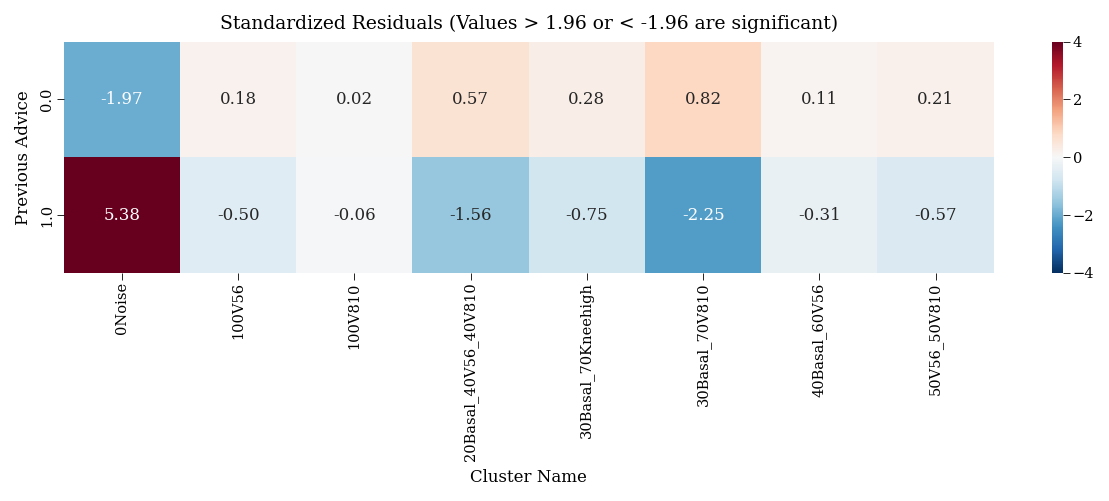

In [110]:
from scipy import stats
contingency_table = pd.crosstab(
    transformed_data.loc[appl_clusters_df.index]['treat_previousadvice'], appl_clusters_df['Cluster name']
)
contingency_table = contingency_table.iloc[:, :]
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

residuals = (contingency_table - expected) / np.sqrt(expected)

plt.figure(figsize=(10, 2))
sns.heatmap(residuals, annot=True, cmap="RdBu_r", center=0, fmt=".2f", vmin=-4, vmax=4)
plt.title("Standardized Residuals (Values > 1.96 or < -1.96 are significant)")
plt.xlabel("Cluster Name")
plt.ylabel("Previous Advice")
plt.show()

In [111]:
appl_clusters_df.join(data['soilpp_sand']).groupby('Cluster name')['soilpp_sand'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster name,,,,,,,,
0Noise,262.0,54.534775,5.809471,43.000000,50.111111,53.222222,59.083333,67.555556
100V56,135.0,53.766255,5.738951,46.111111,49.555556,51.777778,59.000000,67.666667
100V810,86.0,54.788114,5.334358,45.111111,50.694444,55.111111,57.777778,68.444444
20Basal_40V56_40V810,229.0,51.667152,4.532743,43.333333,48.666667,51.333333,53.666667,70.777778
30Basal_70Kneehigh,59.0,55.457627,6.096153,46.111111,51.222222,54.666667,59.333333,72.222222
30Basal_70V810,246.0,53.925926,5.641711,41.000000,50.000000,52.777778,57.416667,70.444444
40Basal_60V56,102.0,57.409586,6.400460,44.777778,51.722222,58.722222,63.111111,67.000000
50V56_50V810,528.0,52.149411,3.856636,43.444444,49.333333,52.000000,54.444444,68.777778


In [112]:
appl_clusters_df.loc[appl_clusters_df['Cluster name']=='0Noise'].filter(like='fertN_').astype(bool).sum(axis=1).value_counts()

2    124
3     86
1     50
4      2
Name: count, dtype: int64

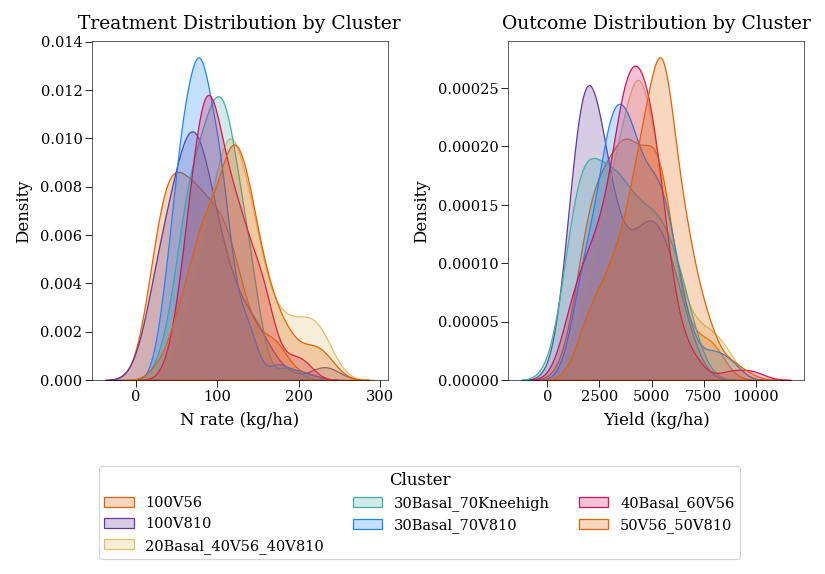

In [113]:
# Check the common support on treatment and outcome for the different clusters
fig, axes = plt.subplots(1, 2, figsize=(5.5, 3))

for c in np.unique(appl_clusters_df['Cluster name'].unique()):
    if c == '0Noise':
        continue
    ax = axes[0]
    sns.kdeplot(
        x=data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            treatment_name
        ],
        fill=True, ax=ax,
        label=f'{c}'
    )
    ax.set_title('Treatment Distribution by Cluster')
    ax.set_xlabel('N rate (kg/ha)')

    ax = axes[1]
    sns.kdeplot(
        x=data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            'outcome_prodkgha'
        ],
        fill=True, ax=ax,
        label=f'{c}'
    )
    ax.set_title('Outcome Distribution by Cluster')
    ax.set_xlabel('Yield (kg/ha)')
plt.tight_layout()
ax.legend(loc='lower center', bbox_to_anchor=(-0.3, -0.55, 0., .0), ncol=3, title='Cluster')
fig.savefig('../figures/N-fertilizer-support-clusters.pdf', bbox_inches='tight', dpi=300)

In [114]:
# Get weights to balance amount on each timing cluster.
from balance import Sample

appl_clusters_df[treatment_name] = data.loc[appl_clusters_df.index, treatment_name]
appl_clusters_df['outcome_prodkgha'] = data.loc[appl_clusters_df.index, 'outcome_prodkgha']

adj_dfs = []
for c in appl_clusters_df['Cluster name'].unique():
    sample = Sample.from_frame(
        appl_clusters_df.loc[appl_clusters_df['Cluster name'] ==  c, [treatment_name]].reset_index(),
        id_column='index'
    )
    target = Sample.from_frame(
        appl_clusters_df.loc[:, [treatment_name]].reset_index(),
        id_column='index'
    )
    sample_with_target = sample.set_target(target)
    adjusted = sample_with_target.adjust(method='cbps', cbps_method='exact', random_seed=RANDOM_SEED)
    adj_dfs.append(adjusted._df)
sample_weights = pd.concat(adj_dfs, axis=0).set_index('index').weight
sample_weights = sample_weights.clip(0.01, 10) # Trim extreme values and set to 10

WARNING (2026-04-09 10:00:16,839) [sample_class/from_frame (line 264)]: No weights passed. Adding a 'weight' column and setting all values to 1
WARNING (2026-04-09 10:00:16,897) [sample_class/from_frame (line 264)]: No weights passed. Adding a 'weight' column and setting all values to 1
INFO (2026-04-09 10:00:16,902) [cbps/cbps (line 411)]: Starting cbps function
INFO (2026-04-09 10:00:16,905) [adjustment/apply_transformations (line 305)]: Adding the variables: []
INFO (2026-04-09 10:00:16,906) [adjustment/apply_transformations (line 306)]: Transforming the variables: ['fertN_total']
INFO (2026-04-09 10:00:16,919) [adjustment/apply_transformations (line 343)]: Final variables in output: ['fertN_total']
INFO (2026-04-09 10:00:16,938) [cbps/cbps (line 461)]: The formula used to build the model matrix: ['fertN_total']
INFO (2026-04-09 10:00:16,940) [cbps/cbps (line 473)]: The number of columns in the model matrix: 10
INFO (2026-04-09 10:00:16,941) [cbps/cbps (line 474)]: The number of row

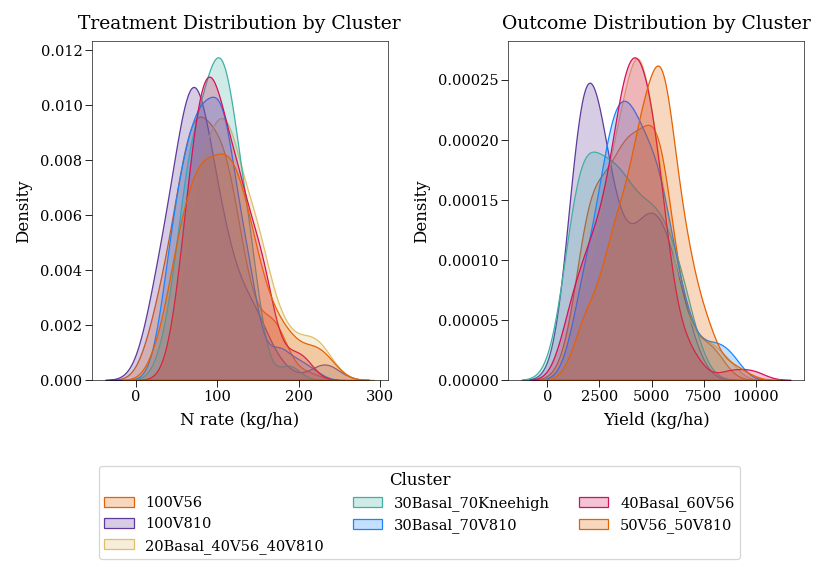

In [115]:
# Check the common support on treatment and outcome for the different clusters
fig, axes = plt.subplots(1, 2, figsize=(5.5, 3))

for c in np.unique(appl_clusters_df['Cluster name'].unique()):
    if c == '0Noise':
        continue
    ax = axes[0]
    sns.kdeplot(
        x=data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            treatment_name
        ],
        fill=True, ax=ax,
        label=f'{c}',
        weights=sample_weights
    )
    ax.set_title('Treatment Distribution by Cluster')
    ax.set_xlabel('N rate (kg/ha)')

    ax = axes[1]
    sns.kdeplot(
        x=data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            'outcome_prodkgha'
        ],
        fill=True, ax=ax,
        label=f'{c}',
        weights=sample_weights
    )
    ax.set_title('Outcome Distribution by Cluster')
    ax.set_xlabel('Yield (kg/ha)')
plt.tight_layout()
ax.legend(loc='lower center', bbox_to_anchor=(-0.3, -0.55, 0., .0), ncol=3, title='Cluster')
fig.savefig('../figures/N-fertilizer-support-clusters-balanced.pdf', bbox_inches='tight', dpi=300)

In [116]:
# data_backup = transformed_data.copy()
# transformed_data = data_backup.copy()

In [117]:
# Add the timing dummies to the data. Note that the noise dummy is not added
timing_dummies = pd.get_dummies(appl_clusters_df['Cluster name'], prefix='timing', drop_first=True).astype(int)
transformed_data = pd.concat([transformed_data, timing_dummies], axis=1)
features.extend(timing_dummies.columns)

In [118]:
transformed_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
0to100perc_season_prec,1647.0,-0.036580,0.972276,-2.934035,-0.756687,-0.070246,0.643470,3.239819
0to100perc_season_rainydays,1647.0,-0.019335,0.973318,-2.894605,-0.747727,0.010411,0.742171,2.396117
0to100perc_season_srad,1647.0,-0.006264,1.007544,-2.334936,-0.836210,0.002694,0.796912,2.859159
0to100perc_season_tmean,1647.0,0.037428,0.944008,-3.568994,-0.693700,0.120474,0.697683,3.493034
0to10perc_season_prec,1647.0,-0.015416,0.998443,-2.016432,-0.863043,-0.045436,0.695369,4.275970
...,...,...,...,...,...,...,...,...
timing_20Basal_40V56_40V810,1647.0,0.139041,0.346094,0.000000,0.000000,0.000000,0.000000,1.000000
timing_30Basal_70Kneehigh,1647.0,0.035823,0.185904,0.000000,0.000000,0.000000,0.000000,1.000000
timing_30Basal_70V810,1647.0,0.149362,0.356554,0.000000,0.000000,0.000000,0.000000,1.000000
timing_40Basal_60V56,1647.0,0.061931,0.241103,0.000000,0.000000,0.000000,0.000000,1.000000


# Effect estimation pipeline

## Generalized propensity score

In [119]:
x_names = list(timing_dummies.columns)
w_names = list(sorted(set(features) - set(x_names)))

training_idxs, testing_idxs = train_test_split(index_zone_subset, random_state=RANDOM_SEED)
print(f"{len(training_idxs)} training samples")
print(f"{len(testing_idxs)} testing samples")
print(f'N features: {len(x_names)+len(w_names)}')

1235 training samples
412 testing samples
N features: 94


In [120]:
# First we need a model for the treatment
X_train = transformed_data.loc[training_idxs, w_names + x_names]
t_train = transformed_data.loc[training_idxs, treatment_name]

optimizer_treatment = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

model_treatment, cv_scores_treatment = optimizer_treatment.cv_optimize(
    X_train, t_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=50, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [121]:
model_treatment = model_treatment.fit(X_train, t_train)
test_score = r2_score(
    y_true=transformed_data.loc[testing_idxs, treatment_name],
    y_pred=model_treatment.predict(transformed_data.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_treatment):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(t_train, model_treatment.predict(X_train)):.3f}')

CV R2 mean: 0.159
Test R2: 0.194
Train R2: 0.661


In [122]:
pd.Series(
    model_treatment.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

fieldsize_value           0.076602
herbicide_any             0.043057
fertN_56leaves            0.038521
fertN_810leaves           0.028222
fertN_basal               0.022445
timing_100V56             0.021681
variety_hybrid            0.020308
planting_handhoe          0.017872
50to60perc_season_srad    0.017814
40to50perc_season_prec    0.017399
dtype: float64

<Axes: ylabel='Count'>

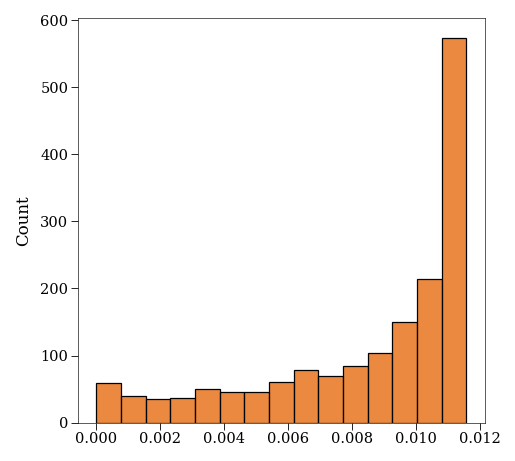

In [123]:
# Use Zhu et al. (2018) and Hirano and Gimbens (2004) approach to estimate PS for continuous treatments
T = transformed_data.loc[:, treatment_name].values
# Get the CV predictions to estimate the variance of residuals
T_pred = cross_val_predict(
    model_treatment, 
    X=transformed_data.loc[:, w_names + x_names],
    y=transformed_data.loc[:, treatment_name]
)
T_res = T - T_pred
res_var = np.var(T_res)

# Estimate the GPS
# gps = (1/(np.sqrt(2*np.pi*res_var)))*np.exp((-1/(2*res_var))*treatment_res**2)
gps_density = stats.norm.pdf(
    T, 
    loc=T_pred, 
    scale=res_var**.5 # Scale is sd in this function
)
sns.histplot(gps_density)

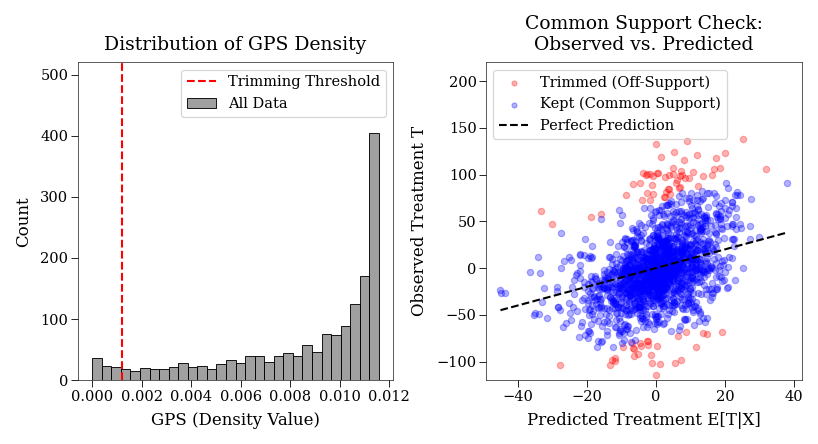

In [124]:
threshold = np.quantile(gps_density, 0.05)
mask_support = gps_density >= threshold
fig, axes = plt.subplots(1, 2, figsize=(5.5, 3))
ax = axes[0]

sns.histplot(gps_density, bins=30, ax=axes[0], color='grey', label='All Data')
ax.axvline(threshold, color='red', linestyle='--', label='Trimming Threshold')
ax.set_title("Distribution of GPS Density")
ax.set_xlabel("GPS (Density Value)")
ax.legend()
ax.set_ylim(0, 520)


ax = axes[1]
ax.scatter(T_pred[~mask_support], T[~mask_support], alpha=0.3, color='red', label='Trimmed (Off-Support)')
ax.scatter(T_pred[mask_support], T[mask_support], alpha=0.3, color='blue', label='Kept (Common Support)')
ax.plot([min(T_pred), max(T_pred)], [min(T_pred), max(T_pred)], 'k--', lw=1, label='Perfect Prediction')

ax.set_title("Common Support Check:\nObserved vs. Predicted")
ax.set_xlabel("Predicted Treatment E[T|X]")
ax.set_ylabel("Observed Treatment T")
ax.legend(loc='upper left', facecolor='none')
ax.set_ylim(-120, 220)
# ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
fig.savefig('../figures/N-fertilizer-gps-support.pdf', bbox_inches='tight', dpi=300)

In [125]:
4/.5

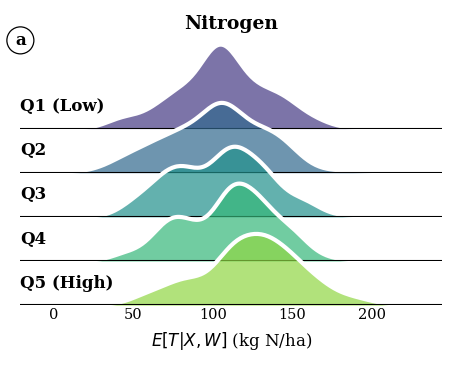

In [126]:
spatial_t = spatial_transformer_fertilizer.predict()
spatial_t = spatial_t[~np.isnan(spatial_t)] 
tmp_df = pd.DataFrame({'T_pred': (T_pred + spatial_t)[mask_support], 'Strata': pd.qcut(T[mask_support], 5, labels=False)})

g = sns.FacetGrid(tmp_df, row="Strata", hue="Strata", aspect=7, height=.5, palette="viridis")
g.map(sns.kdeplot, "T_pred", clip_on=False, fill=True, alpha=0.7, lw=0)
g.map(sns.kdeplot, "T_pred", clip_on=False, color="w", lw=2)

g.fig.subplots_adjust(hspace=-.5)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.axes.flat[0].set_title("Nitrogen", fontweight='bold', y=.99) 
g.axes.flat[-1].set_xlabel(r'$E[T|X,W]$'+' (kg N/ha)')

# Optional: Add text labels for each stratum
for ax, label in zip(g.axes.flat, ["Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"]):
    ax.text(0, 0.2, label, fontweight="bold", transform=ax.transAxes)
    ax.axhline(0, color='k', linestyle="-")
    ax.set_facecolor('none')
    # ax.grid(None)
    ax.tick_params(length=0)

g.axes.flat[0].text(
    0, 1, 'a', transform=g.axes.flat[0].transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)


g.fig.savefig('../figures/N-fertilizer-gps-support-strata.pdf', bbox_inches='tight', dpi=300)

In [127]:
# Trim extreme residuals
transformed_data_pstrimmed = transformed_data.copy()
transformed_data_pstrimmed = transformed_data_pstrimmed.loc[gps_density > threshold]

In [128]:
# transformed_data_pstrimmed = transformed_data.copy()
index_zone_subset = transformed_data_pstrimmed.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data_pstrimmed.shape

## Outcome model $q(X, W)$

In [129]:
training_idxs = training_idxs.intersection(index_zone_subset)
testing_idxs = testing_idxs.intersection(index_zone_subset)
X_train = transformed_data_pstrimmed.loc[training_idxs, w_names + x_names]
t_train = transformed_data_pstrimmed.loc[training_idxs, treatment_name]
T = transformed_data_pstrimmed.loc[:, treatment_name].values

In [130]:
y_train = transformed_data_pstrimmed.loc[training_idxs, outcome_name]

optimizer_q = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

model_q, cv_scores_q = optimizer_q.cv_optimize(
    X_train, y_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=100, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [131]:
model_q = model_q.fit(X_train, y_train)
test_score = r2_score(
    y_true=transformed_data_pstrimmed.loc[testing_idxs, outcome_name],
    y_pred=model_q.predict(transformed_data_pstrimmed.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_q):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(y_train, model_q.predict(X_train)):.3f}')

CV R2 mean: 0.026
Test R2: 0.051
Train R2: 0.336


In [132]:
pd.Series(
    model_q.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

fieldsize_value             0.066335
fertN_56leaves              0.034642
herbicide_any               0.033961
0to10perc_season_srad       0.025562
0to100perc_season_prec      0.024271
0to10perc_season_tmean      0.021811
90to100perc_season_srad     0.021714
fertN_810leaves             0.021236
90to100perc_season_tmean    0.021058
treat_previousadvice        0.020858
dtype: float64

## Effect estimation with DML 

In [133]:
from econml.dml import LinearDML
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures, add_dummy_feature
from sklearn.multioutput import MultiOutputRegressor

In [134]:
sandy_series = transformed_data_pstrimmed['soil_sandy'].to_numpy()
legume_series = transformed_data_pstrimmed['history_legume'].to_numpy()
sandy_series.mean()

In [135]:
# Homogeneous effect: Response curve is a line and it does not depend on timing
X_sand = np.vstack([~sandy_series.astype(bool), sandy_series]).T
W = transformed_data_pstrimmed.loc[:,features]
Y = transformed_data_pstrimmed.loc[:, outcome_name].to_numpy()
T = transformed_data_pstrimmed.loc[:, treatment_name].to_numpy()

lineardml_hom_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED, 
    fit_cate_intercept=False,
)
lineardml_hom_estimate = lineardml_hom_estimate.fit(
    Y=Y, T=T, W=W, X=X_sand,
    inference='statsmodels', cache_values=True,
)
lineardml_hom_estimate.summary(feature_names=['Non-sandy', 'Sandy'])

CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
Non-sandy,12.17,1.657,7.344,0.0,8.923,15.418
Sandy,9.868,1.989,4.962,0.0,5.97,13.766


In [136]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
cubic_spline_transformer = SplineTransformer(
    degree=3, n_knots=4, include_bias=True,
    knots='uniform',
)

# Transform the absolute T, and fit one Spatial Transformer for each component
# of the transformed T.
T_absolute = data.loc[transformed_data_pstrimmed.index, treatment_name].to_numpy()
T_trans = cubic_spline_transformer.fit_transform(T_absolute.reshape(-1, 1))
T_spline_spatial_avg = np.zeros_like(T_trans) # Spatial average vector for the Transformed treatment
for i in range(T_trans.ndim):
    t_col = T_trans[:, i]
    spatial_transformer = SpatialTransform(
        points.geometry, maxlag=50e3, esitmator='cressie',
        model='matern', n_lags=50, use_nugget=True
    )
    spatial_transformer.fit(t_col)
    t_trans_col = spatial_transformer.transform_demean() 
    T_spline_spatial_avg[:, i] = t_col - np.where(np.isnan(t_trans_col), 0, t_trans_col)

def spatial_anomaly_transform(t):
    return t - T_spline_spatial_avg

spatial_anomaly_transformer = FunctionTransformer(spatial_anomaly_transform)
treatment_featurizer = Pipeline([
    ('spline', cubic_spline_transformer),
    ('spatial anomaly', spatial_anomaly_transformer)
])

In [137]:
# Amount heterogeneous: response is a curve and it does not depend on timing
lineardml_amount_estimate = LinearDML(
    model_y=model_q, 
    model_t=MultiOutputRegressor(model_treatment), 
    treatment_featurizer=treatment_featurizer,
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False, 
)
lineardml_amount_estimate = lineardml_amount_estimate.fit(
    Y=Y, T=T_absolute.reshape(-1, 1), W=W, X=X_sand,
    inference='statsmodels', cache_values=True,
)

In [138]:
spatial_y = pd.Series( # Vector of spatial average for Y.
    spatial_transformer_yield.predict(), index=spatial_trans_index
).loc[index_zone_subset].to_numpy()

param_cov_matrix = lineardml_amount_estimate._ortho_learner_model_final._model_final._model._param_var
param = lineardml_amount_estimate._ortho_learner_model_final._model_final._model._param

T0 = T_absolute.mean() # Reference or base fertilizer amount
def rate_inference(X, T0=T0, T1=100, y_offset=0, scale=1):
    """
    Function to make inference on the fitted estimator. We do this because the inference
    in the original object struggles with the spatial transformation when a subset of 
    the data is used
    """
    t_change = cubic_spline_transformer.transform([[T1]]) - cubic_spline_transformer.transform([[T0]])
    x_final_model = []
    for j in range(t_change.shape[1]):
        # For each element in t_change, multiply it with both columns of X_sand
        x_final_model.append(X * t_change[0, j])
    x_final_model = np.hstack(x_final_model)

    ate = (x_final_model.mean(axis=0).reshape(1, -1) @ param.reshape(-1, 1))[0, 0]
    ate_se = np.sqrt(
        x_final_model.mean(axis=0).reshape(1, -1) @ 
        param_cov_matrix @ 
        x_final_model.mean(axis=0).reshape(-1, 1)
    )[0, 0]

    # Calculate confidence interval
    ci_mean_lower = ate - 1.96 * ate_se
    ci_mean_upper = ate + 1.96 * ate_se

    # Calculate p-value
    if ate_se != 0:
        t_stat = ate / ate_se
        p_value = 2 * stats.norm.sf(np.abs(t_stat))
    else:
        p_value = np.nan # Or 1.0 if se is 0 and ate is also 0

    return {
        'mean_point': ate/scale, 
        'stderr_mean': ate_se/scale,
        'ci_mean_lower': ci_mean_lower/scale,
        'ci_mean_upper': ci_mean_upper/scale,
        'pvalue': p_value
    }

In [139]:
ate_df = pd.DataFrame(
    columns=['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue'], 
    index=pd.MultiIndex(names=('Estimate', 'Soil'), levels=[[], []], codes=[[], []])
)
t25, t75 = np.quantile(T_absolute, [.25, .75])
ate_df.loc[('Amount rate', 'ATE'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_sand, T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df.loc[('Amount rate', 'Sandy'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_sand[X_sand[:, 1]==1], T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df.loc[('Amount rate', 'Non-sandy'), ['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue']] = \
    list(rate_inference(X_sand[X_sand[:, 0]==1], T0=t25, T1=t75, y_offset=0, scale=(t75-t25)).values())
ate_df

Mean        SE   LowerCI    UpperCI    pvalue
Estimate    Soil                                                         
Amount rate ATE        12.501882  1.855131  8.865826  16.137938       0.0
            Sandy      11.846994  2.841805  6.277055  17.416932  0.000031
            Non-sandy  13.001723  2.448517   8.20263  17.800816       0.0

In [140]:
# Timing hetrogeneous: response is a line, but it is different for each of the timing clusters
W = transformed_data_pstrimmed.loc[:, list(set(features) - set(x_names))].to_numpy()
X = transformed_data_pstrimmed.loc[:, x_names].to_numpy()
X = np.hstack([(1 - X.any(axis=1)).reshape(-1, 1), X]) # Add a feature for the other cluster category
X = np.hstack([X * ~sandy_series.astype(bool).reshape((-1, 1)), X * sandy_series.reshape((-1, 1))])

x_names_cate = ['other'] + x_names
x_names_cate = [f'{j}_{i}' for j in ('nosandy', 'sandy') for i in x_names_cate]

lineardml_time_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False,
)
lineardml_time_estimate = lineardml_time_estimate.fit(
    Y=Y, T=T, W=W, X=X,
    inference='statsmodels', cache_values=True,
    sample_weight=sample_weights[transformed_data_pstrimmed.index]
)
print('Timing heterogeneous effect on Non-sandy:')
lineardml_time_estimate.ate_inference(X[X_sand[:, 0]==1])

Timing heterogeneous effect on Non-sandy:


In [141]:
print('Timing heterogeneous effect on Sandy:')
lineardml_time_estimate.ate_inference(X[X_sand[:, 1]==1])

Timing heterogeneous effect on Sandy:


In [142]:
T_absolute = data.loc[transformed_data_pstrimmed.index, treatment_name].to_numpy()
T_bins = np.arange(20, 200, 20)
def transform_to_bins(t):
    dummies = pd.get_dummies(pd.cut(t.flatten(), T_bins)).astype(int).to_numpy()
    return dummies
bin_transformer = FunctionTransformer(transform_to_bins) 

In [143]:
# Amount heterogeneous but using bins response is a curve and it does not depend on timing
X_bins = bin_transformer.fit_transform(T_absolute)
X_bins_sand = np.hstack([
    X_bins*X_sand[:, 0].reshape(-1,1),
    X_bins*X_sand[:, 1].reshape(-1,1),
])

lineardml_amountcat_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False, 
)
lineardml_amountcat_estimate = lineardml_amountcat_estimate.fit(
    Y=Y, T=T, W=W, X=X_bins_sand,
    inference='statsmodels', cache_values=True,
)
print('Amount heterogeneous bins effect on Non-sandy:')
x_bin_sand_names = [f'{s}sand:{i}-{i+10}' for s in ('no', '') for i in T_bins[:-1]]
lineardml_amountcat_estimate.summary(feature_names=x_bin_sand_names)

Amount heterogeneous bins effect on Non-sandy:
CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
nosand:20-30,15.157,11.911,1.273,0.203,-8.187,38.502
nosand:40-50,12.173,6.82,1.785,0.074,-1.194,25.541
nosand:60-70,18.683,5.967,3.131,0.002,6.989,30.378
nosand:80-90,16.354,5.63,2.905,0.004,5.319,27.39
nosand:100-110,15.548,5.907,2.632,0.008,3.971,27.125
nosand:120-130,7.974,8.132,0.981,0.327,-7.965,23.912
nosand:140-150,10.137,5.271,1.923,0.054,-0.193,20.468
nosand:160-170,15.147,6.367,2.379,0.017,2.667,27.627
sand:20-30,11.692,5.066,2.308,0.021,1.762,21.622
sand:40-50,13.75,6.142,2.239,0.025,1.712,25.789


In [144]:
lineardml_time_estimate.score_, lineardml_amount_estimate.score_, lineardml_hom_estimate.score_, lineardml_amountcat_estimate.score_

## Visualize effects

In [145]:
maize_std = clean_data.loc[index_zone_subset].maizeprodkg_ha.std()
maize_mean = clean_data.loc[index_zone_subset].maizeprodkg_ha.mean()
cluster_count_soil = appl_clusters_df.join(transformed_data_pstrimmed.soil_sandy).groupby(['soil_sandy', 'Cluster name']).cluster.count()

In [146]:
# ATE for the different model setups
estimates_dict = {
    'No Het.': lineardml_hom_estimate, 'Amount rate': lineardml_amount_estimate,
    'Amount Cat.': lineardml_amountcat_estimate, 'Appl. Strat.': lineardml_time_estimate, 
}
# ate_df = pd.DataFrame(
#     columns=['Mean', 'SE', 'LowerCI', 'UpperCI', 'pvalue'], 
#     index=pd.MultiIndex(names=('Estimate', 'Soil'), levels=[[], []], codes=[[], []])
# )
for est_name, est in estimates_dict.items():
    for n, soil in enumerate(('Non-sandy', 'Sandy')):
        # ate_df.loc[(est_name, soil)] = soil
        if est_name in ('No Het.', 'Amount rate'):
            if est_name == 'Amount rate':
                continue
            X_ = X_sand
        elif est_name == 'Amount Cat.':
            X_ = X_bins_sand
        else:
            X_ = X
        ate_df.loc[(est_name, 'ATE'), 'Mean'] = est.ate(X_)
        ate_df.loc[(est_name, 'ATE'), 'SE'] = est.ate_inference(X_).mean_pred_stderr 
        ate_df.loc[(est_name, 'ATE'), 'pvalue'] = est.ate_inference(X_).pvalue()
        ate_df.loc[(est_name, 'ATE'), ['LowerCI', 'UpperCI']] = est.ate_interval(X_)
        X_ = X_[X_sand[:, n]==1]
        ate_df.loc[(est_name, soil), 'Mean'] = est.ate(X_)
        ate_df.loc[(est_name, soil), 'SE'] = est.ate_inference(X_).mean_pred_stderr 
        ate_df.loc[(est_name, soil), 'pvalue'] = est.ate_inference(X_).pvalue()
        ate_df.loc[(est_name, soil), ['LowerCI', 'UpperCI']] = est.ate_interval(X_)

ate_df = ate_df.sort_index()

In [147]:
ate_df.loc[(slice(None), slice('ATE')), :].style.format({
    'Mean': '{:.1f}', 'SE': '{:.3f}', 'pvalue': '{:.3f}'
})

,,Mean,SE,LowerCI,UpperCI,pvalue
Estimate,Soil,,,,,
Amount Cat.,ATE,12.3,1.580,9.177953,15.371755,0.000
Amount rate,ATE,12.5,1.855,8.865826,16.137938,0.000
Appl. Strat.,ATE,12.1,1.372,9.397989,14.776351,0.000
No Het.,ATE,11.2,1.275,8.675703,13.671734,0.000


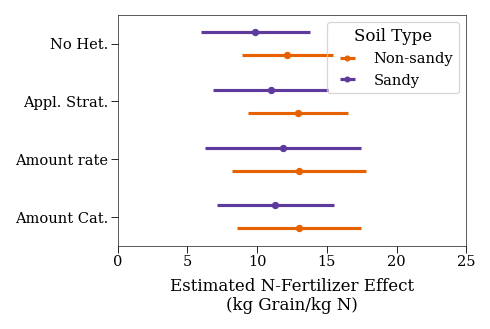

In [148]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

for soil in ('Non-sandy', 'Sandy'):
    tmp_soil_df = ate_df.loc[(slice(None), soil), :].reset_index(level=1)
    y = np.arange(len(tmp_soil_df)) - (0.2 if soil == 'Non-sandy' else -0.2)
    ax.errorbar(
        y=y,
        x=tmp_soil_df['Mean'],
        xerr=np.abs(tmp_soil_df[['LowerCI', 'UpperCI']].values.T - tmp_soil_df['Mean'].values),
        fmt='o', linewidth=1.5, label=soil
    )
ax.set_yticks(np.arange(len(tmp_soil_df)))
ax.set_yticklabels(tmp_soil_df.index)
ax.set_xlabel('Estimated N-Fertilizer Effect\n(kg Grain/kg N)')
ax.set_ylim(-0.5, 3.5)
# ax.set_title('Sample N-AE from\nthe different estimators')
ax.set_xlim(0, 25)
# ax.axvline(cf_estimator.ate(X) * maize_std/100, color='k', linestyle='--', label='ATE')
ax.legend(title='Soil Type',loc='upper right', facecolor='none')

In [149]:
timing_pretty_names = {
    'other': 'Other', 
    'timing_100V56': '100% V5-6', 
    'timing_100V810': '100% V8-10', 
    'timing_20Basal_40V56_40V810': '20% Basal, 40% V5-6, 40% V8-10', 
    'timing_30Basal_70Kneehigh': '30% Basal, 70% Knee-high', 
    'timing_30Basal_70V810': '30% Basal, 70% V8-10', 
    'timing_50V56_50V810': '50% V5-6, 50% V8-10',
    'timing_40Basal_60V56': '40% Basal, 60% V5-6'
}

In [150]:
cluster_count_soil

soil_sandy  Cluster name        
0.0         0Noise                  116
            100V56                   86
            100V810                  28
            20Basal_40V56_40V810    139
            30Basal_70Kneehigh       26
            30Basal_70V810          154
            40Basal_60V56            75
            50V56_50V810            263
1.0         0Noise                  123
            100V56                   37
            100V810                  50
            20Basal_40V56_40V810     82
            30Basal_70Kneehigh       33
            30Basal_70V810           85
            40Basal_60V56            26
            50V56_50V810            241
Name: cluster, dtype: int64

In [151]:
cluster_count_soil.index = cluster_count_soil.index.map({
    (0.0, '0Noise'): ('Non-sandy', 'Other'),
    (0.0, '100V56'): ('Non-sandy', '100% V5-6'),
    (0.0, '100V810'): ('Non-sandy', '100% V8-10'),
    (0.0, '20Basal_40V56_40V810'): ('Non-sandy', '20% Basal, 40% V5-6, 40% V8-10'),
    (0.0, '30Basal_70Kneehigh'): ('Non-sandy', '30% Basal, 70% Knee-high'),
    (0.0, '30Basal_70V810'): ('Non-sandy', '30% Basal, 70% V8-10'),
    (0.0, '50V56_50V810'): ('Non-sandy', '50% V5-6, 50% V8-10'),
    (0.0, '40Basal_60V56'): ('Non-sandy', '40% Basal, 60% V5-6'),
    (1.0, '0Noise'): ('Sandy', 'Other'),
    (1.0, '100V56'): ('Sandy', '100% V5-6'),
    (1.0, '100V810'): ('Sandy', '100% V8-10'),
    (1.0, '20Basal_40V56_40V810'): ('Sandy', '20% Basal, 40% V5-6, 40% V8-10'),
    (1.0, '30Basal_70Kneehigh'): ('Sandy', '30% Basal, 70% Knee-high'),
    (1.0, '30Basal_70V810'): ('Sandy', '30% Basal, 70% V8-10'),
    (1.0, '50V56_50V810'): ('Sandy', '50% V5-6, 50% V8-10'),
    (1.0, '40Basal_60V56'): ('Sandy', '40% Basal, 60% V5-6'),
 })

CATE Intercept Results:  No intercept was fitted!


point_estimate  stderr  zstat  \
Non-sandy Other                                   11.524   3.799  3.033   
          100% V5-6                                6.875   6.705  1.025   
          100% V8-10                              20.334   7.266  2.799   
          20% Basal, 40% V5-6, 40% V8-10           9.592   3.908  2.454   
          30% Basal, 70% Knee-high                31.146   7.633  4.081   
          30% Basal, 70% V8-10                    14.250   6.106  2.334   
          40% Basal, 60% V5-6                     10.524   8.211  1.282   
          50% V5-6, 50% V8-10                     14.660   2.497  5.872   
Sandy     Other                                    7.493   3.872  1.935   
          100% V5-6                               11.655   5.380  2.166   
          100% V8-10                               5.492   3.710  1.480   
          20% Basal, 40% V5-6, 40% V8-10          16.783   6.089  2.756   
          30% Basal, 70% Knee-high                17.444   6.858  2.543   
          30% Basal, 70% V8-10                    26.764   8.262  3.239   
          40% Basal, 60% V5-6                     26.257  14.677  1.789   
          50% V5-6, 50% V8-10                      3.683   3.635  1.013   

                                          pvalue  ci_lower  ci_upper  
Non-sandy Other                            0.002     4.077    18.970  
          100% V5-6                        0.305    -6.267    20.016  
          100% V8-10                       0.005     6.094    34.575  
          20% Basal, 40% V5-6, 40% V8-10   0.014     1.932    17.251  
          30% Basal, 70% Knee-high         0.000    16.186    46.106  
          30% Basal, 70% V8-10             0.020     2.283    26.218  
          40% Basal, 60% V5-6              0.200    -5.569    26.616  
          50% V5-6, 50% V8-10              0.000     9.767    19.553  
Sandy     Other                            0.053    -0.096    15.082  
          100% V5-6                        0.030     1.110    22.201  
          100% V8-10                       0.139    -1.779    12.763  
          20% Basal, 40% V5-6, 40% V8-10   0.006     4.848    28.718  
          30% Basal, 70% Knee-high         0.011     4.002    30.887  
          30% Basal, 70% V8-10             0.001    10.571    42.957  
          40% Basal, 60% V5-6              0.074    -2.510    55.025  
          50% V5-6, 50% V8-10              0.311    -3.442    10.808

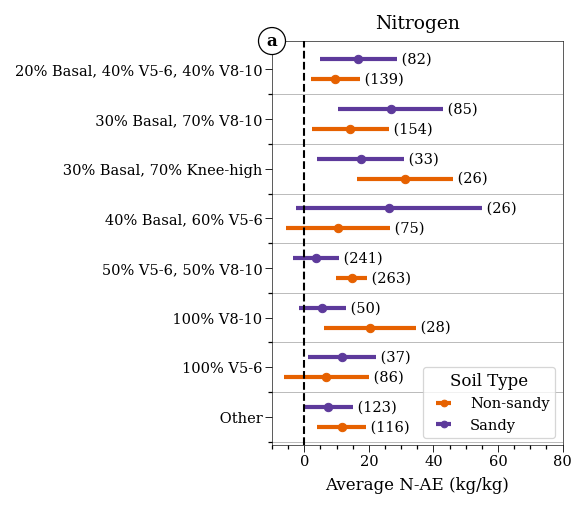

In [ ]:

def rename_soil_cluster(i):
    soil = i.split('_')[0]
    soil = 'Sandy' if soil == 'sandy' else 'Non-sandy'
    appl = '_'.join(i.split('_')[1:])
    return (soil, timing_pretty_names[appl])
timing_coefs = pd.read_html(
    lineardml_time_estimate.summary(feature_names=x_names_cate).tables[0].as_html()
    , header=0, index_col=0
)[0]
timing_coefs.index = timing_coefs.index.map(rename_soil_cluster)

cluster_order = [
    'Other', # Noise
    '100% V5-6', '100% V8-10', '50% V5-6, 50% V8-10', # Only top 
    '40% Basal, 60% V5-6',  # Basal and Early stages
    '30% Basal, 70% Knee-high', '30% Basal, 70% V8-10', # Basal and Late stages
    '20% Basal, 40% V5-6, 40% V8-10' # Split applications
]

tmp_df = timing_coefs # Convert to N-AE

fig, ax = plt.subplots(1, 1, figsize=(2.5, 3.5))
y = np.arange(tmp_df.loc['Sandy'].shape[0])
for soil in ('Non-sandy', 'Sandy'):
    tmp_tmp_df = tmp_df.loc[soil].loc[cluster_order]
    y_offset = y + (0.2 if soil == 'Sandy' else -0.2)
    ax.errorbar(
        y=y_offset,
        x=tmp_tmp_df['point_estimate'],
        xerr=np.abs(tmp_tmp_df[['ci_lower', 'ci_upper']].values.T - tmp_tmp_df['point_estimate'].values),
        fmt='o', linewidth=2, label=soil, markersize=4
    )
    for n, cluster in enumerate(cluster_order[::]):
        ax.text(
            tmp_tmp_df.loc[cluster, 'ci_upper'], y_offset[n], 
            f' ({cluster_count_soil.loc[(soil, cluster)]}) ',
            ha='left', va='center', fontsize=7
        )
ax.text(
    0, 1, 'a', transform=ax.transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)
ax.set_title('Nitrogen')
# ax.set_xlabel('Average N-Fertilizer Effect\n(kg Grain/Kg N)')
ax.set_xlabel('Average N-AE (kg/kg)')
# ax.set_ylim(-0.5, len(x_names)+0.5)
ax.set_xlim(-10, 80)
# ax.set_title('Songwe region')
ax.axvline(0, color='k', linestyle='--')
ax.set_yticks(y)
ax.set_yticks(y-.5, minor=True)
ax.grid(which='minor', axis='y', linestyle='-')
ax.grid(which='major', axis='y', linewidth=0)
ax.set_xticks(np.arange(-10, 80, 5), minor=True)
# ax.grid(which='minor', axis='x', linestyle=':')
# ax.grid(which='major', axis='x', linestyle=':')
ax.set_yticklabels([f'{i:>30}' for i in cluster_order])
ax.legend(loc='lower right', title='Soil Type')
# ax.set_title("Effect of N-fertilizer for\ndifferent application strategies")

fig.savefig('../figures/N-fertilizer-timing-effects.pdf', bbox_inches='tight', dpi=300)
# fig.savefig('../figures/poster/N-fertilizer-timing-effects.png', bbox_inches='tight', dpi=1200)
tmp_df

In [153]:
T_absolute = data.loc[transformed_data_pstrimmed.index, treatment_name].to_numpy()
Y_absolute = data.loc[transformed_data_pstrimmed.index, 'outcome_prodkgha'].to_numpy()

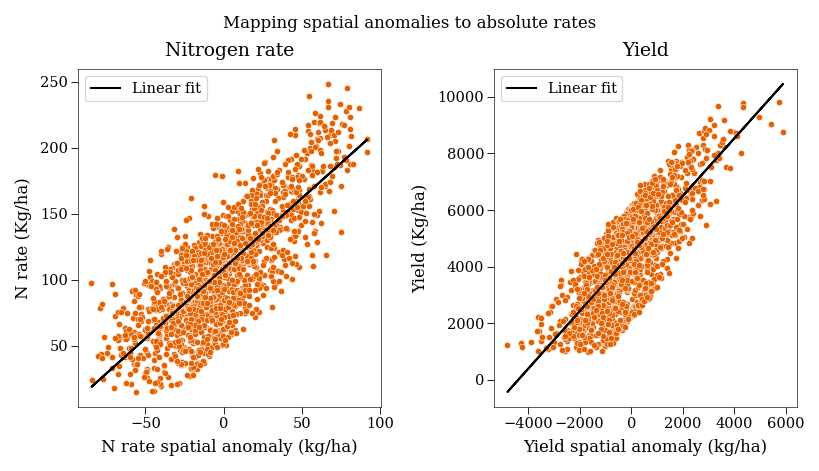

In [154]:
from statsmodels.api import OLS, add_constant

# A model to map spaital anomalies to absolute rates
fertilizer_anomaly_to_absolute = OLS(
    endog=T_absolute,
    exog=add_constant(T)
).fit()

yield_anomaly_to_absolute = OLS(
    endog=Y_absolute,
    exog=add_constant(Y)
).fit()

fig, axes = plt.subplots(1, 2, figsize=(5.5, 3))

ax = axes[0]
sns.scatterplot(x=T, y=T_absolute, ax=ax)
ax.set_xlabel('N rate spatial anomaly (kg/ha)')
ax.set_ylabel('N rate (Kg/ha)')
ax.plot(
    T, fertilizer_anomaly_to_absolute.predict(add_constant(T)), 
    color='k', linestyle='-', label='Linear fit'
)
plt.tight_layout()
ax.set_title('Nitrogen rate')
ax.legend()

ax = axes[1]
sns.scatterplot(x=Y, y=Y_absolute, ax=ax)
ax.set_xlabel('Yield spatial anomaly (kg/ha)')
ax.set_ylabel('Yield (Kg/ha)')
ax.plot(
    Y, yield_anomaly_to_absolute.predict(add_constant(Y)), 
    color='k', linestyle='-', label='Linear fit'
)
plt.tight_layout()
ax.set_title('Yield')
ax.legend()

fig.suptitle('Mapping spatial anomalies to absolute rates', y=1.02)

fertilizer_anomaly_to_absolute.rsquared, yield_anomaly_to_absolute.rsquared

Around 60% of the yield and nitrogen rates is not explained by spatial patterns. 

In [155]:
spatial_t = pd.Series(
    spatial_transformer_fertilizer.predict(), index=spatial_trans_index
).loc[index_zone_subset].to_numpy()
spatial_y = pd.Series(
    spatial_transformer_yield.predict(), index=spatial_trans_index
).loc[index_zone_subset].to_numpy()
# sns.regplot(
#     x=spatial_t, y=spatial_y 
# )

In [156]:
spatial_y_avg = np.nanmean(spatial_y) 
spatial_t_avg = np.nanmean(spatial_t)
print(f'Average spatial N Rate: {spatial_y_avg:.0f} Kg N/ha')
print(f'Average spatial N Rate: {spatial_t_avg.mean():.0f} Kg N/ha')
spatial_n_avg = 110

Average spatial N Rate: 4464 Kg N/ha
Average spatial N Rate: 109 Kg N/ha


In [157]:
Y_absolute.mean(), spatial_y_avg

In [158]:
t_grid = np.linspace(np.percentile(T, 2.5), np.percentile(T, 97.5), 100)
t_absolute_grid = fertilizer_anomaly_to_absolute.predict(add_constant(t_grid))

def plot_response_curve(est, ax, X=None, ci=True, kwargs_line={}, kwargs_ci={},
                        anomaly=True, t_grid=None):
    lift_inference = []
    if t_grid is None: 
        t_grid = np.linspace(np.percentile(T, 2.5), np.percentile(T, 97.5), 100)
    if isinstance(est, LinearDML):
        for t in t_grid: 
            if ci:
                ate_inf = est.ate_inference(X=X, T0=T0, T1=t)
                lift_inference.append((ate_inf.mean_point, *ate_inf.conf_int_mean()))
            else:
                lift_inference.append([est.ate(X=X, T0=0, T1=t)])
    elif est.shape[0] == 3:
        lift_inference = est.T
    else:
        lift_inference = est.reshape(-1, 1)
            
    lift_inference = np.array(lift_inference)
    if anomaly:
        t_grid_ = t_grid 
        lift_inference_ = lift_inference
    else:
        lift_inference_ = lift_inference + spatial_y_avg
        t_grid_ = t_grid + spatial_n_avg
    
    sns.lineplot(
        x=t_grid_, y=lift_inference_[:, 0], ax=ax,
        **kwargs_line
    )
    if ci:
        if not kwargs_ci:
            kwargs_ci=dict(alpha=.1)
        ax.fill_between(
            x=t_grid_, y1=lift_inference_[:,1], 
            y2=lift_inference_[:,2], **kwargs_ci
        )
    if anomaly:
        ax.set_xlabel('N-Fertilizer rate (kg/ha)')
        ax.set_ylabel('Change in yield compared to using\nthe average N rate (kg/ha)')
    else:
        ax.set_xlabel('N-Fertilizer rate (kg/ha)')
        ax.set_ylabel('Yield (kg/ha)')

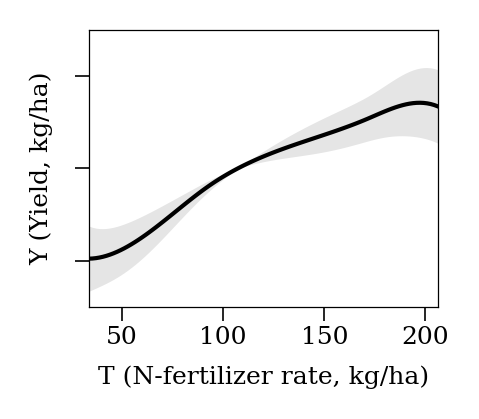

In [ ]:
t_grid = np.linspace(np.percentile(T_absolute, 2.5), np.percentile(T_absolute, 97.5), 100)
lift_inference_rate = {
    'All': np.zeros(shape=(3, len(t_grid))),
    'Non-sandy': np.zeros(shape=(3, len(t_grid))),
    'Sandy': np.zeros(shape=(3, len(t_grid)))
}
for n, t in enumerate(t_grid): 
    ate_inf = rate_inference(X_sand, T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['All'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    ate_inf = rate_inference(X_sand[X_sand[:, 1]==0], T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['Non-sandy'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    ate_inf = rate_inference(X_sand[X_sand[:, 1]==1], T0=T0, T1=t, y_offset=spatial_y)
    lift_inference_rate['Sandy'][:, n] = (ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper'])
    

fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.2), dpi=300)
plot_response_curve(
    lift_inference_rate['All'], ax, t_grid=t_grid,
    kwargs_line=dict(color='k'), kwargs_ci=dict(color='k', alpha=.1, linewidth=0)
)
ax.set_yticklabels([])
ax.set_ylim(-1500, 1500)
ax.set_ylabel('Y (Yield, kg/ha)', fontsize=6)
ax.set_xlabel('T (N-fertilizer rate, kg/ha)', fontsize=6)
ax.set_xticks(np.arange(0, t_grid.max(), 50))
ax.set_xlim(t_grid.min(), t_grid.max())
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6)
fig.savefig('../figures/all-N-fertilizer-dose-response.svg', bbox_inches='tight', dpi=300, transparent=True)
# fig.savefig('../figures/poster/all-N-fertilizer-dose-response.png', bbox_inches='tight', dpi=1200)

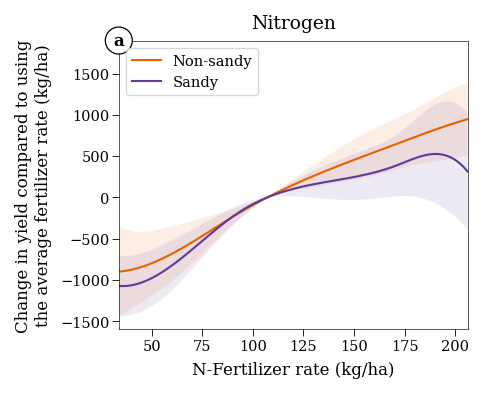

In [ ]:
fig, ax =plt.subplots(1, 1, figsize=(3, 2.5))
plot_response_curve(
    lift_inference_rate['Non-sandy'], ax, X=X_sand[X_sand[:,0].astype(bool)],
    kwargs_line=dict(label='Non-sandy'), t_grid=t_grid
)
plot_response_curve(
    lift_inference_rate['Sandy'], ax, X=X_sand[X_sand[:,1].astype(bool)],
    kwargs_line=dict(label='Sandy'), t_grid=t_grid
)

ax.set_title('Average N-fertilizer response')

ax.set_xlabel('N-Fertilizer rate (kg/ha)')
ax.set_title('Nitrogen')
ax.legend(loc='upper left')
ax.text(
    0, 1, 'a', transform=ax.transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)
# ax.set_yticks(np.arange(-1600, 2500, 500))
# ax.set_yticks(np.arange(-1600, 2500, 100), minor=True)
ax.grid(which='minor', linestyle=':')
ax.set_ylabel('Change in yield compared to using\nthe average fertilizer rate (kg/ha)')
ax.set_ylim(-1600, 1900)
ax.set_xlim(t_grid.min(), t_grid.max())

# ax.set_xlim(0, 100*T.max())
fig.savefig('../figures/N-fertilizer-dose-response-curve.pdf', bbox_inches='tight', dpi=300)
# fig.savefig('../figures/poster/N-fertilizer-dose-response-curve.png', bbox_inches='tight', dpi=1200)

In [161]:
pd.DataFrame([Y_absolute, T_absolute, X_sand[:, 1]]).T.groupby(2).mean()

,0,1
2,,
0.0,4634.850483,112.011177
1.0,4164.228751,101.076113


Text(0.5, 1.0, 'Distribution of N fertilizer application rates\n(spatial anomaly)')

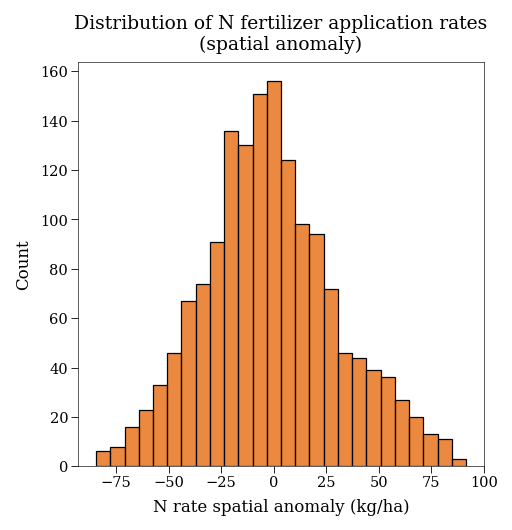

In [162]:
ax = sns.histplot(T)
ax.set_xlabel('N rate spatial anomaly (kg/ha)')
ax.set_title('Distribution of N fertilizer application rates\n(spatial anomaly)')

In [163]:
spatial_t_mean_sand = pd.DataFrame([
    spatial_t, X_sand[:, 1] 
]).T.groupby(1).mean().iloc[:, 0]
spatial_t_mean_sand.index = ['Non-sandy', 'Sandy']
spatial_t_mean_sand.name = 'N spatial mean'
spatial_t_mean_sand

Non-sandy    113.132754
Sandy        103.148902
Name: N spatial mean, dtype: float64

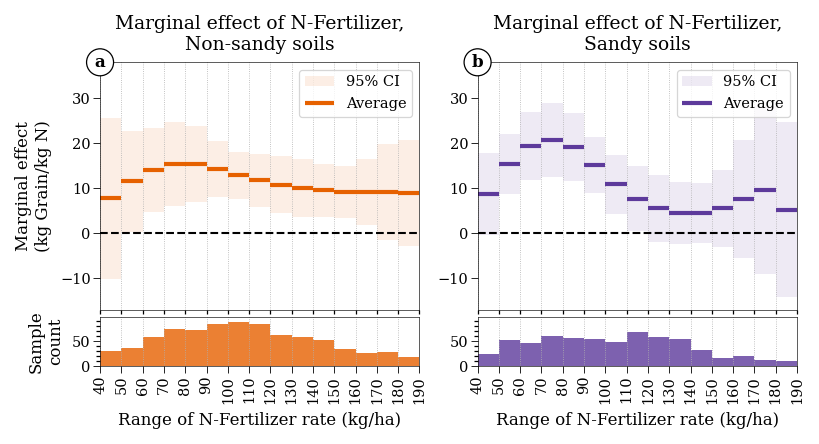

In [164]:
# Marginal response for amount ranges
cycle_colors = [i['color'] for i in plt.rcParams['axes.prop_cycle']]
step_size = 10
fig, axes = plt.subplots(2, 2, figsize=(5.5, 3), sharey=False, sharex=False, height_ratios=[5, 1])

x_ = np.arange(0, 200, step_size)
x = np.arange(40, 200, step_size)
x_ = x 
lift_amount_df = pd.DataFrame(
    columns=pd.MultiIndex.from_tuples([
        ('Non-sandy', 'Mean'), ('Non-sandy', 'LowerCI'), ('Non-sandy', 'UpperCI'),
        ('Sandy', 'Mean'), ('Sandy', 'LowerCI'), ('Sandy', 'UpperCI')
    ]), index=x_[:-1]
)
for n, soil in enumerate(('Non-sandy', 'Sandy')):
    ax = axes[0][n]
    ax2 = axes[1][n]
    ax.axhline(0, color='k', linestyle='--')
    lift_inference = []
    for i, t in enumerate(x[:-1]):
        t1 = x[i+1]
        ate_inf = rate_inference(X=X_sand[X_sand[:, n].astype(bool)],  T0=t, T1=t1)
        lift_inference.append(
            np.array([ate_inf['mean_point'], ate_inf['ci_mean_lower'], ate_inf['ci_mean_upper']])/(t1 - t)
        )
        lift_amount_df.loc[t, (soil, slice(None))] = lift_inference[-1]
        T_ = T_absolute[X_sand[:, n].astype(bool)]
        # ax.text(
        #     x_[i] + (x_[i+1] - x_[i])/2, lift_inference[-1][2]+1, f'({((T_ >= t) & (T_ < t1)).sum()})', 
        #     ha='center', fontsize=7
        # )
        ax.fill_between(
            x=[x_[i], x_[i+1]], y1=lift_inference[-1][1], y2=lift_inference[-1][2],
            alpha=0.1, color=cycle_colors[n], linewidth=0, label='95% CI' if i==0 else None
        )

        ax2.fill_between(
            x=[x_[i], x_[i+1]], y1=0, y2=((T_ >= t) & (T_ < t1)).sum(),
            alpha=.8, color=cycle_colors[n], linewidth=0, label='95% CI' if i==0 else None
        )
    lift_inference = np.array(lift_inference)
    err = np.abs(lift_inference[:, 1:] - lift_inference[:, 0].reshape(-1, 1)).T 
    ax.hlines(
        y=lift_inference[:, 0], xmin=x_[:-1], xmax=x_[1:], linewidth=2,
        label='Average', color=cycle_colors[n]
    )
    if n == 0: ax.set_ylabel('Marginal effect\n(kg Grain/kg N)')
    ax.set_xticks(x_[:])
    # ax.set_yticks(np.arange(-50, 100, 2), minor=True)
    ax.grid(which='major', linestyle=':', axis='x')
    # ax.grid(which='minor', linestyle='-')
    ax.set_ylim(-17, 38)
    ax.set_xlim(x_[0], x_[-1])
    ax.set_title(f'Marginal effect of N-Fertilizer,\n{soil} soils')
    ax.text(
        0, 1, ('a', 'b')[n], transform=ax.transAxes, va='center', ha='center', fontsize=8,
        fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
    )
    ax.set_xticks(ax.get_xticks(), minor=True)
    ax.set_xticks([], minor=False)
    ax.grid(which='minor', linestyle=':', axis='x')
    # ax.set_xticks([-900, 900], minor=False)
    ax.legend(loc='upper right')
    # Histplot
    ax2.set_ylim(0, 99)
    ax2.set_xticks(x_[:])
    ax2.set_xlim(x_[0], x_[-1])
    ax2.set_yticks(np.arange(0, 100, 10), minor=True)
    ax2.grid(which='major', linestyle=':', axis='x')
    # ax2.grid(which='minor', linestyle='-')
    ax2.set_xticklabels([f'{x_[i]:.0f}' for i, _ in enumerate(x_[:])], rotation=90)
    ax2.set_xlabel('Range of N-Fertilizer rate (kg/ha)')
    # ax2.yaxis.tick_right()
    # ax2.yaxis.set_label_position("right")
    if n == 0: ax2.set_ylabel('Sample\ncount',)
plt.tight_layout()
plt.subplots_adjust(hspace=.05)


# fig.suptitle(f'Average marginal effect of N Fertilizer for\ngiven  {step_size} kg/ha N fertilizer ranges', y=1.05)
fig.savefig('../figures/N-fertilizer-marginal-dose-response.pdf', bbox_inches='tight', dpi=300)
lift_amount_df['Fertilizer rate'] = lift_amount_df.index + T_absolute.mean()
lift_amount_df.style.format(precision=1)

CATE Intercept Results:  No intercept was fitted!


Non-sandy                   Sandy                
          LowerCI    Mean UpperCI LowerCI    Mean UpperCI
bin_low                                                  
20         -8.187  15.157  38.502   1.762  11.692  21.622
40         -1.194  12.173  25.541   1.712  13.750  25.789
60          6.989  18.683  30.378   9.350  18.678  28.006
80          5.319  16.354  27.390   3.427  13.952  24.477
100         3.971  15.548  27.125  -6.907   2.417  11.741
120        -7.965   7.974  23.912  -4.073   9.349  22.771
140        -0.193  10.137  20.468  -1.044  17.313  35.670
160         2.667  15.147  27.627  -5.234  10.780  26.794

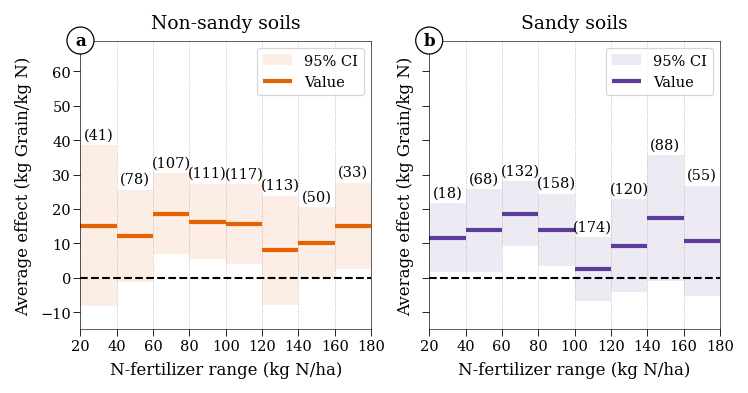

In [165]:
t_bins_coefs_df = pd.read_html(
    lineardml_amountcat_estimate.summary(feature_names=x_bin_sand_names).tables[0].as_html()
    , header=0, index_col=0
)[0]
t_bins_coefs_df['soil'] = t_bins_coefs_df.index.map(lambda x: x.split(':')[0])
t_bins_coefs_df['bin_low'] = t_bins_coefs_df.index.map(lambda x: x.split(':')[1].split('-')[0]).astype(int)

t_bins_coefs_df = pd.pivot_table(
    t_bins_coefs_df,
    values=['point_estimate', 'ci_lower', 'ci_upper'],
    columns=['soil'],
    index='bin_low'
)
t_bins_coefs_df.columns = pd.MultiIndex.from_tuples([
        ('Non-sandy', 'LowerCI'), ('Sandy', 'LowerCI'), ('Non-sandy', 'UpperCI'),
        ('Sandy', 'UpperCI'), ('Non-sandy', 'Mean'), ('Sandy', 'Mean')
    ])
t_bins_coefs_df = t_bins_coefs_df.sort_index()
t_bins_coefs_df

# Marginal response for quantile ranges
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5), sharey=True, sharex=False)
x = t_bins_coefs_df.index
x_ = x

for n, soil in enumerate(('Non-sandy', 'Sandy')):
    ax = axes[n]
    ax.axhline(0, color='k', linestyle='--')
    tmp_df = t_bins_coefs_df.loc[:, soil]
    T_ = T_absolute[X_sand[:, int('Non' in soil)].astype(bool)]
    for t, row in tmp_df.iterrows():
        ax.text(
            t + 10, row.UpperCI+2, f'({((T_ >= t) & (T_ < t+20)).sum()})', 
            ha='center', fontsize=7
        )
        ax.fill_between(
            x=[t, t+20], y1=row.LowerCI, y2=row.UpperCI,
            alpha=0.1, color=cycle_colors[n], linewidth=0, 
            label='95% CI' if t==T_bins[0] else None,
        )
        ax.hlines(
            y=row.Mean, xmin=t, xmax=t+20, linewidth=2,
            label='Value' if t == T_bins[0] else None,
            color=cycle_colors[n]
        )
        ax.set_xlabel('N-fertilizer range (kg N/ha)')
        ax.set_ylabel('Average effect (kg Grain/kg N)')
        ax.set_xticks(T_bins)
        # ax.set_xticklabels([f'{x_[i]:.0f}' for i, _ in enumerate(x_[:])], rotation=90)
        # ax.set_xticklabels([f'${{{i*100:.0f}}}^{{th}}$' for i in q], rotation=90)
        ax.set_xlim(T_bins[0], T_bins[-1])
        ax.set_title(f'{soil} soils')
        ax.set_ylim(-15, 69)
        # ax.set_yticks(np.arange(-16, 69, 2), minor=False)
        ax.grid(which='major', linestyle=':', axis='x')
        ax.legend(loc='upper right')
    ax.text(
        0, 1, ('a', 'b')[n], transform=ax.transAxes, va='center', ha='center', fontsize=8,
        fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
    )

fig.savefig('../figures/N-fertilizer-dose-category-effect.pdf', bbox_inches='tight', dpi=300)
# pd.DataFrame(lift_inference, columns=['point_estimate', 'ci_lower', 'ci_upper'], index=x)
t_bins_coefs_df.sort_index(axis=1)

# Benchmark models

## Causal OLS

In [166]:
from statsmodels.api import OLS

In [167]:
# OLS model for homogeneous effect
ols_model_hom = OLS(
    endog=transformed_data_pstrimmed[outcome_name],
    exog=transformed_data_pstrimmed[features].join([
        (transformed_data_pstrimmed[treatment_name] * 
         (transformed_data_pstrimmed['soil_sandy'].astype(bool))).rename('N_sandy'),
        (transformed_data_pstrimmed[treatment_name] * 
         (~transformed_data_pstrimmed['soil_sandy'].astype(bool))).rename('N_nosandy')
    ]),
).fit().summary()
pd.read_html(
    ols_model_hom.tables[1].as_html()
    , header=0, index_col=0
)[0].loc[['N_sandy', 'N_nosandy']]

,coef,std err,t,P>|t|,[0.025,0.975]
N_sandy,8.5218,1.769,4.817,0.0,5.052,11.992
N_nosandy,9.3585,1.447,6.467,0.0,6.520,12.197


In [168]:
# OLS model for variable timing
endog = transformed_data_pstrimmed[outcome_name]
exog = transformed_data_pstrimmed[w_names]
exog = pd.concat([
    exog,
    pd.DataFrame(
        np.multiply(transformed_data_pstrimmed[[treatment_name]].to_numpy(), X),
        index=exog.index, columns=x_names_cate
    )
], axis=1)
ols_model_time = OLS(
    endog=endog,
    exog=exog,
).fit(sample_weight=sample_weights[transformed_data_pstrimmed.index]).summary()
pd.read_html(
    ols_model_time.tables[1].as_html()
    , header=0, index_col=0
)[0].loc[x_names_cate] 

,coef,std err,t,P>|t|,[0.025,0.975]
nosandy_other,9.9581,3.670,2.713,0.007,2.759,17.157
nosandy_timing_100V56,4.5811,4.177,1.097,0.273,-3.613,12.775
nosandy_timing_100V810,24.5168,6.055,4.049,0.000,12.640,36.394
nosandy_timing_20Basal_40V56_40V810,7.3943,3.089,2.394,0.017,1.335,13.453
nosandy_timing_30Basal_70Kneehigh,26.2508,8.053,3.260,0.001,10.454,42.047
nosandy_timing_30Basal_70V810,5.8533,4.176,1.402,0.161,-2.337,14.044
nosandy_timing_40Basal_60V56,7.5735,4.379,1.729,0.084,-1.017,16.164
nosandy_timing_50V56_50V810,12.8385,2.487,5.162,0.000,7.960,17.717
sandy_other,8.2836,3.388,2.445,0.015,1.638,14.929
sandy_timing_100V56,6.8668,5.956,1.153,0.249,-4.816,18.550


## Predictive ML

In [169]:
from sklearn.base import clone
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
# A RF with PDP to simulate the effect of fertilizer on yield
# This article was just released and it uses PDP: https://www.sciencedirect.com/science/article/pii/S1161030125004216
# X_rf_response = np.hstack([W, T.reshape(-1, 1)])

data_ml_pred = data.copy() # This uses all data, so the effect identification phase is skipped
data_ml_pred = data_ml_pred.drop(columns=['crop_name', 'crop_maize', 'outcome_prodkgha'])
data_ml_pred = data_ml_pred.loc[transformed_data_pstrimmed.index]
data_ml_pred[treatment_name] = transformed_data_pstrimmed[treatment_name] + spatial_t
data_ml_pred[outcome_name] = transformed_data_pstrimmed[outcome_name] + spatial_y
X_rf_response = data_ml_pred.drop(columns=[outcome_name])
Y_rf_response = data_ml_pred[outcome_name]
model_rf_response = clone(model_q)
y_cv_pred = cross_val_predict(
    model_rf_response,
    X_rf_response,
    Y_rf_response,
)
model_rf_response = model_rf_response.fit(X_rf_response, Y_rf_response)
r2_score(Y_rf_response, y_cv_pred)

In [170]:
pd.Series(
    model_rf_response.feature_importances_,
    index=X_rf_response.columns
).sort_values(ascending=False).head(10)

soilfert_cec        0.069113
fertN_total         0.060484
lat                 0.049334
fertP_total         0.036992
soilpp_clay         0.034591
soilpp_sand         0.034043
variety_hybrid      0.031059
variety_recycled    0.029969
lon                 0.025740
soilpp_density      0.023403
dtype: float64

In [171]:
X_rf_response_t0 = X_rf_response.copy()
X_rf_response_t1 = X_rf_response.copy()

X_rf_response_t0[treatment_name] = t25
X_rf_response_t1[treatment_name] = t75

model_rf_ite = (
    model_rf_response.predict(X_rf_response_t1) - model_rf_response.predict(X_rf_response_t0)
)/X_rf_response_t1[treatment_name]
model_rf_ite = model_rf_ite.to_frame()
model_rf_ite.describe()

,fertN_total
count,1564.000000
mean,1.860431
std,0.944513
min,-1.276919
25%,1.264126
50%,1.836026
75%,2.451319
max,5.820746


In [172]:
model_rf_ite['Cluster name'] = appl_clusters_df['Cluster name']
model_rf_ite['soil_sandy'] = transformed_data_pstrimmed['soil_sandy']
model_rf_split_gate = model_rf_ite.groupby(['soil_sandy', 'Cluster name'])['fertN_total'].describe()
model_rf_split_gate['se'] = model_rf_split_gate['std'] / np.sqrt(model_rf_split_gate['count'])
model_rf_split_gate[['mean', 'se']]

mean        se
soil_sandy Cluster name                            
0.0        0Noise                1.891299  0.098260
           100V56                1.995110  0.100103
           100V810               2.321886  0.153614
           20Basal_40V56_40V810  1.718818  0.067331
           30Basal_70Kneehigh    2.054415  0.177226
           30Basal_70V810        1.524484  0.085820
           40Basal_60V56         1.887186  0.107195
           50V56_50V810          2.152921  0.054726
1.0        0Noise                1.765720  0.095034
           100V56                2.007792  0.149710
           100V810               1.570874  0.081184
           20Basal_40V56_40V810  1.487689  0.088187
           30Basal_70Kneehigh    2.291939  0.137060
           30Basal_70V810        1.714692  0.088097
           40Basal_60V56         1.764621  0.178667
           50V56_50V810          1.907069  0.061209

In [173]:
rf_response_pdp = partial_dependence(
    model_rf_response, X_rf_response, features=[treatment_name],
    kind='individual'
)

model_rf_response.predict(X_rf_response)

array([2645.47036073, 2873.28291722, 3891.03869887, ..., 5648.34434269,
       5125.69349005, 4356.36285526], shape=(1564,))

In [174]:
rf_response_df_sandy = {}
rf_response_df_nonsandy = {}
rf_response_df = {}
X_rf_response_t0 = X_rf_response.copy()
X_rf_response_t0[treatment_name] = T_absolute.mean()
for t in t_grid:
    X_rf_response_t1 = X_rf_response.copy()
    X_rf_response_t1[treatment_name] = t
    rf_response_df[t] = model_rf_response.predict(X_rf_response_t1) - model_rf_response.predict(X_rf_response_t0)
    rf_response_df_sandy[t] = model_rf_response.predict(X_rf_response_t1.loc[X_rf_response_t1['soil_sandy']]) - \
        model_rf_response.predict(X_rf_response_t0.loc[X_rf_response_t0['soil_sandy']])
    rf_response_df_nonsandy[t] = model_rf_response.predict(X_rf_response_t1.loc[~X_rf_response_t1['soil_sandy']]) - \
        model_rf_response.predict(X_rf_response_t0.loc[~X_rf_response_t0['soil_sandy']])
rf_response_df_sandy = pd.DataFrame(rf_response_df_sandy)
rf_response_df_sandy = pd.melt(rf_response_df_sandy)
rf_response_df_nonsandy = pd.DataFrame(rf_response_df_nonsandy)
rf_response_df_nonsandy = pd.melt(rf_response_df_nonsandy)
rf_response_df = pd.DataFrame(rf_response_df)
rf_response_df = pd.melt(rf_response_df)

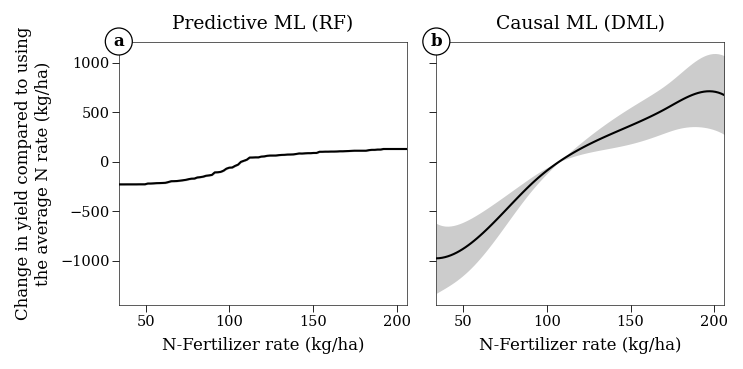

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharex=True, sharey=True)
ax = axes[0]
sns.lineplot(
    rf_response_df,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color='k'
)
ax.set_xlabel('N-Fertilizer rate (kg/ha)')
ax.set_ylabel('Change in yield compared to using\nthe average N rate (kg/ha)')
ax.set_title('Predictive ML (RF)')
ax.set_xlim(t_grid.min(), t_grid.max())

ax = axes[1]
plot_response_curve(
    lift_inference_rate['All'], ax, kwargs_ci=dict(alpha=.2, color='k', linewidth=0), 
    t_grid=t_grid, kwargs_line=dict(color='k')
)
ax.set_title('Causal ML (DML)')
ax.set_xlabel('N-Fertilizer rate (kg/ha)')
ax.set_xlim(t_grid.min(), t_grid.max())

for n, ax in enumerate(axes):
    ax.text(
        0, 1, ('a', 'b')[n], transform=ax.transAxes, va='center', ha='center', fontsize=8,
        fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
    )

# ax.set_xlim(0, 100*T.max())
fig.savefig('../figures/N-fertilizer-predictive-vs-causal.pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()

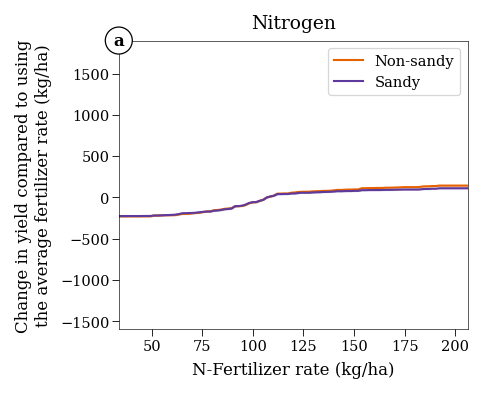

In [177]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5), sharex=True, sharey=True)
sns.lineplot(
    rf_response_df_nonsandy,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color=cycle_colors[0], label='Non-sandy'
)
sns.lineplot(
    rf_response_df_sandy,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color=cycle_colors[1], label='Sandy'
)
ax.set_xlabel('N-Fertilizer rate (kg/ha)')
ax.set_title('Nitrogen')
ax.set_xlim(t_grid.min(), t_grid.max())
ax.set_ylim(-1600, 1900)
ax.text(
    0, 1, ('a', 'b')[0], transform=ax.transAxes, va='center', ha='center', fontsize=8,
    fontweight='bold', bbox=dict(boxstyle='circle', fc='w', ec='k')
)
ax.set_ylabel('Change in yield compared to using\nthe average fertilizer rate (kg/ha)')
# ax.set_xlim(0, 100*T.max())
fig.savefig('../figures/N-fertilizer-predictive.pdf', bbox_inches='tight', dpi=300)
fig.savefig('../figures/poster/N-fertilizer-predictive.png', bbox_inches='tight', dpi=1200)

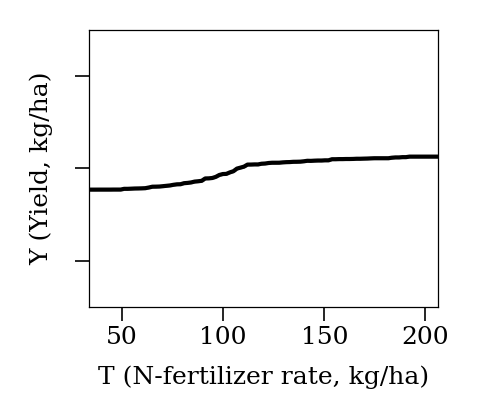

In [183]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.2), dpi=300)
sns.lineplot(
    rf_response_df,
    x='variable',
    y='value',
    errorbar='se', ax=ax,
    color='k'
)
ax.set_ylim(-1500, 1500)

ax.set_yticklabels([])
ax.set_ylabel('Y (Yield, kg/ha)', fontsize=6)
ax.set_xlabel('T (N-fertilizer rate, kg/ha)', fontsize=6)
ax.set_xticks(np.arange(0, t_grid.max(), 50))
ax.set_xlim(t_grid.min(), t_grid.max())
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6)
fig.savefig('../figures/all-N-fertilizer-dose-response-predictive.svg', bbox_inches='tight', dpi=300, transparent=True)
fig.savefig('../figures/poster/all-N-fertilizer-dose-response-predictive.png', bbox_inches='tight', dpi=1500)

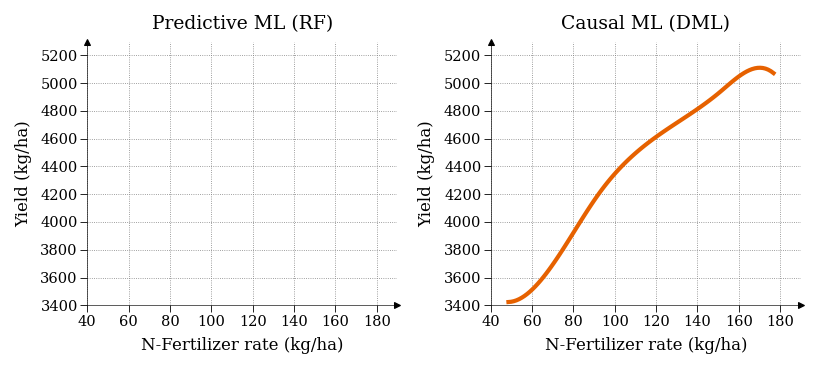

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5), sharex=True, sharey=False)
ax = axes[0]
sns.lineplot(
    x=np.repeat(rf_response_pdp['grid_values'][0], len(Y)),
    y=rf_response_pdp['individual'][0].T.flatten(),
    errorbar=None, ax=ax, linewidth=2
)

ax.set_title('Predictive ML (RF)')

ax = axes[1]
plot_response_curve(
    lift_inference_rate['All'], ax, kwargs_ci=dict(alpha=.2), 
    ci=False, kwargs_line=dict(linewidth=2)
)
ax.set_title('Causal ML (DML)')

for ax in axes:
    xticks = np.arange(-70, 90, 20)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks+110)
    yticks = np.arange(-1000, 900, 200)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks+4400)
    ax.set_xlabel('N-Fertilizer rate (kg/ha)')
    ax.set_ylabel('Yield (kg/ha)')
    ax.set_xlim(xticks[0], xticks[-1]+10)
    ax.set_ylim(yticks[0], yticks[-1]+100)

    ax.grid(linestyle=':', color='grey')
    ax.set_facecolor('w')
    ax.spines['left'].set_color('k')
    ax.spines['bottom'].set_color('k')
    ax.spines['right'].set_color(None)
    ax.spines['top'].set_color(None)
    ax.plot(1, 0, ">k", transform=ax.transAxes, clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.transAxes, clip_on=False)

# ax.text(5.2, 0.1, 'X', fontsize=12, fontweight='bold')

# ax.set_xticklabels([''])
plt.tight_layout()

# Sensitivity analysis

In [84]:
lineardml_hom_estimate.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
   6.442       8.949 11.267      13.585   16.089
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                    0.22                 0.175
----------------------------------------------
"""

In [85]:
lineardml_time_estimate.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
   6.566       9.045 11.327      13.609   16.076
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.224                 0.179
----------------------------------------------
"""

In [86]:
lineardml_amountcat_estimate.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
================================================
CI Lower Theta Lower Theta  Theta Upper CI Upper
------------------------------------------------
   6.807       9.655 12.261      14.868    17.71
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.214                 0.168
----------------------------------------------
"""

## Placebo test

In [87]:
from tqdm import tqdm

In [88]:
t25, t75

In [89]:
# Run placebo for the Timing and Amount heterogeneous estimators
placebo_ate_estimates_dict = {
    'No Het.': [],
    'Amount rate': [],
    'Amount Cat.': [],
    'Appl. Strat.': []
}
# placebo_ate_estimates_dict['Amount rate'] = []
placebo_rate_response = []
placebo_t_grid = np.quantile(T, np.linspace(0.025, 0.975, 100))

N_PLACEBO_RUNS = 0
if N_PLACEBO_RUNS < 1:
    with open('N-response-placebo', 'rb') as f:
        placebo_ate_estimates_dict, placebo_rate_response = pickle.load(f)

for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T_absolute, size=len(T_absolute), replace=True)
    # Heterogeneous by amount
    lineardml_amount_placebo = LinearDML(
        model_y=model_q, 
        model_t=MultiOutputRegressor(model_treatment), 
        treatment_featurizer=treatment_featurizer,
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_amount_placebo = lineardml_amount_placebo.fit(
        Y=Y, T=T_placebo.reshape(-1, 1), W=W, X=X_sand,
        inference='statsmodels', cache_values=True,
    )
    placebo_ate_estimates_dict['Amount rate'].append(lineardml_amount_placebo.ate(X_sand, T0=t25, T1=t75)/(t75-t25))
    placebo_rate_response.append(
        np.array([
            lineardml_amount_placebo.ate(X_sand, T0=0, T1=i) 
            for i in np.quantile(T_placebo, np.linspace(0.025, 0.975, 100))
        ])
    )

0it [00:00, ?it/s]


In [90]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by time
    lineardml_time_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_time_placebo = lineardml_time_placebo.fit(
        Y=Y, T=T_placebo, W=W, X=X,
        inference='statsmodels', cache_values=True,
        sample_weight=sample_weights[transformed_data_pstrimmed.index]
    )
    placebo_ate_estimates_dict['Appl. Strat.'].append(lineardml_time_placebo.ate(X))

0it [00:00, ?it/s]


In [91]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by Soil 
    lineardml_time_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False,
    )
    lineardml_time_placebo = lineardml_time_placebo.fit(
        Y=Y, T=T_placebo, W=W, X=X_sand,
        inference='statsmodels', cache_values=True,
    )
    placebo_ate_estimates_dict['No Het.'].append(lineardml_time_placebo.ate(X_sand))

0it [00:00, ?it/s]


In [92]:
for _ in tqdm(range(N_PLACEBO_RUNS)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Rate heterogeneous with binned rates
    lineardml_amountcat_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False, 
    )
    lineardml_amountcat_placebo = lineardml_amountcat_placebo.fit(
        Y=Y, T=T_placebo, W=W, X=X_bins_sand,
        inference='statsmodels', cache_values=True,
    )
    placebo_ate_estimates_dict['Amount Cat.'].append(lineardml_amountcat_placebo.ate(X))

0it [00:00, ?it/s]


In [93]:
with open('N-response-placebo', 'wb') as f:
    pickle.dump((placebo_ate_estimates_dict, placebo_rate_response), f)

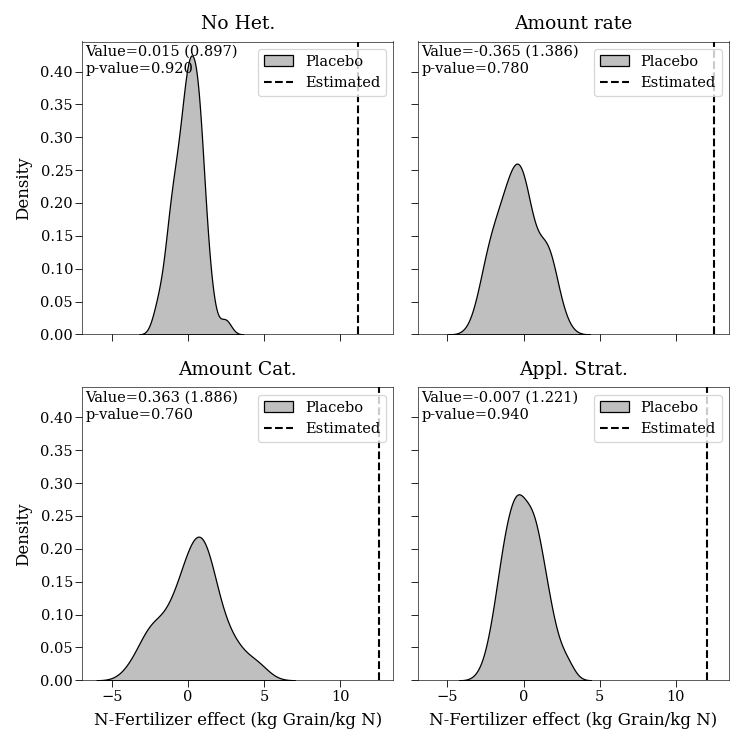

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(5, 5), sharex=True, sharey=True)
axes = axes.flatten()
for n, (est_name, placebo_estimates) in enumerate(placebo_ate_estimates_dict.items()):
    ax = axes[n]
    sns.kdeplot(np.array(placebo_estimates).flatten(), label='Placebo', ax=ax, color='k', fill=True)
    ax.set_xlabel('N-Fertilizer effect (kg Grain/kg N)')
    ax.set_title(est_name)
    ate_ = ate_df.loc[(est_name, 'ATE')]['Mean']
    ax.axvline(ate_, label='Estimated', color='k', linestyle='--')
    p_value = 2*min((np.array(placebo_estimates) >= 0).mean(), (np.array(placebo_estimates) < 0).mean())
    ax.text(
        0.01, 0.99, 
        f'Value={np.mean(placebo_estimates):.3f} ({np.std(placebo_estimates):.3f})', 
        transform=ax.transAxes, va='top', fontsize=7
    )
    ax.text(
        0.01, 0.93, f"p-value={p_value:.3f}", transform=ax.transAxes, 
        va='top', fontsize=7
    )
    ax.legend(loc='upper right')
    # ax.set_xlim(-30, 25)
plt.tight_layout()
fig.savefig('../figures/N-fertilizer-ate-placebo-tests.pdf', bbox_inches='tight', dpi=300)

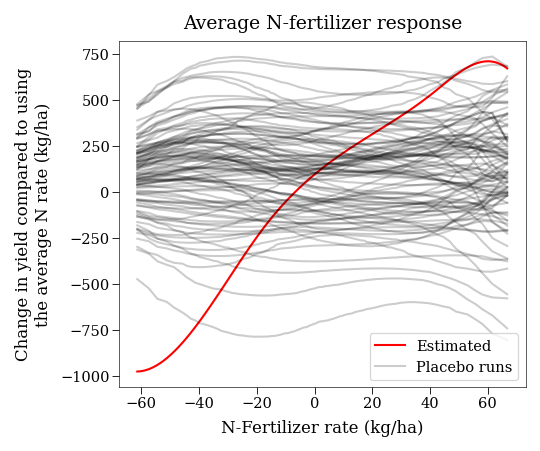

In [95]:
fig, ax =plt.subplots(1, 1, figsize=(3.5, 3))
plot_response_curve(
    lift_inference_rate['All'], ax, ci=False, 
    kwargs_line=dict(label='Estimated', color='r'), 
)
for est in placebo_rate_response:
    plot_response_curve(
        est, ax, ci=False, kwargs_line=dict(color='k', alpha=.2),
        X=X_sand, t_grid=placebo_t_grid
    )
plot_response_curve(
    est, ax, ci=False, kwargs_line=dict(color='k', alpha=.2, label='Placebo runs'),
    X=X_sand, t_grid=placebo_t_grid
)

ax.set_title('Average N-fertilizer response')
# ax.set_xlim(t_grid.min(), t_grid.max())

# ax.set_xlim(0, 100*T.max())
ax.legend()
fig.savefig('../figures/N-fertilizer-dose-response-curve-placebo.pdf', bbox_inches='tight', dpi=300)

In [96]:
columns_stats = []
for n in adjustment_nodes:
    if n not in ('weather', 'soil', 'fertilizerTiming'):
        columns_stats += columns_dict[n] 

In [97]:
stats_survey = data.loc[index_zone_subset][
    columns_stats + ["outcome_prodkgha", treatment_name, 'soil_sandy'] + 
    [f'fert{"P" if "N" in treatment_name else "N"}_total']
].astype(float).describe().T[['mean', 'std', 'min', 'max']]

cat_map = {i: k for k, v in columns_dict.items() for i in v}
cat_map['outcome_prodkgha'] = 'outcome'
stats_survey.index = pd.MultiIndex.from_tuples([
    (cat_map[i], i)
    for i in stats_survey.index
])
stats_survey['range'] = stats_survey.apply(lambda row: f"{row['min']:.3f} - {row['max']:.3f}", axis=1)
stats_survey = stats_survey.drop(columns=['min', 'max'])
stats_survey.sort_index().style.format({'mean': '{:.3f}', 'sd': '{:.3f}'})

In [98]:
transformed_data_pstrimmed.shape

In [99]:
fert_timing_stats = data.loc[index_zone_subset].filter(like='fertN').describe().T[['mean', 'std', 'min', 'max']]
fert_timing_stats = pd.concat([
    fert_timing_stats, 
    data.loc[index_zone_subset].loc[data.fertP_total > 0].filter(like='fertP').describe().T[['mean', 'std', 'min', 'max']]
])
fert_timing_stats = fert_timing_stats.drop(['fertN_total', 'fertP_total'])
fert_timing_stats['range'] = fert_timing_stats.apply(lambda row: f"{row['min']:.3f} - {row['max']:.3f}", axis=1)
fert_timing_stats = fert_timing_stats.drop(columns=['min', 'max'])
fert_timing_stats.sort_index().style.format({'mean': '{:.3f}', 'sd': '{:.3f}'})

,mean,std,range
fertN_56leaves,0.355,0.314662,0.000 - 1.000
fertN_810leaves,0.406,0.307041,0.000 - 1.000
fertN_basal,0.120,0.156021,0.000 - 0.736
fertN_emergence,0.036,0.140459,0.000 - 1.000
fertN_kneehigh,0.070,0.214025,0.000 - 1.000
fertN_tasselingsilking,0.014,0.092316,0.000 - 1.000
fertP_56leaves,0.182,0.377796,0.000 - 1.000
fertP_810leaves,0.015,0.080601,0.000 - 0.600
fertP_basal,0.690,0.450808,0.000 - 1.000
fertP_emergence,0.112,0.309755,0.000 - 1.000


In [100]:
env_stats = data.loc[index_zone_subset].filter(like='0to100').describe().drop(columns=data.filter(like='90to').columns).T[['mean', 'std', 'min', 'max']]
env_stats = pd.concat([
    env_stats,
    data.loc[index_zone_subset].filter(like='soil').drop(columns=['soil_sandy', 'residue_incorporateinthesoil']).describe().T[['mean', 'std', 'min', 'max']]
])
env_stats['range'] = env_stats.apply(lambda row: f"{row['min']:.3f} - {row['max']:.3f}", axis=1)
env_stats = env_stats.drop(columns=['min', 'max'])
env_stats.sort_index().style.format({'mean': '{:.3f}', 'sd': '{:.3f}'})

,mean,std,range
0to100perc_season_prec,6.796,1.100485,3.520 - 10.482
0to100perc_season_rainydays,0.590,0.076186,0.364 - 0.778
0to100perc_season_srad,17.627,0.631005,16.146 - 19.440
0to100perc_season_tmean,20.164,0.966396,16.467 - 23.713
soilfert_cec,25.295,1.382113,20.000 - 29.667
soilfert_oc,23.654,1.772089,18.778 - 29.556
soilpp_clay,29.285,4.283757,18.333 - 39.667
soilpp_density,133.273,4.281221,109.889 - 146.000
soilpp_sand,53.427,5.274925,41.000 - 72.222


In [101]:
print(stats_survey.sort_index().style.format({'mean': '{:.3f}', 'sd': '{:.3f}'}).to_latex().replace('_', '\_'))

\begin{tabular}{llrrl}
 &  & mean & std & range \\
\multirow[c]{2}{*}{fertilizerAmount} & fertN\_total & 107.278 & 42.880322 & 15.199 - 248.489 \\
 & fertP\_total & 16.062 & 17.103287 & 0.000 - 103.383 \\
\multirow[c]{7}{*}{fieldHistory} & fieldsize\_value & 0.615 & 0.532407 & 0.043 - 4.076 \\
 & history\_legume & 0.135 & 0.341737 & 0.000 - 1.000 \\
 & history\_maize & 0.841 & 0.365986 & 0.000 - 1.000 \\
 & history\_maizelegume & 0.031 & 0.172533 & 0.000 - 1.000 \\
 & history\_nocrop & 0.030 & 0.170783 & 0.000 - 1.000 \\
 & history\_oilseed & 0.031 & 0.174264 & 0.000 - 1.000 \\
 & history\_rootandtuber & 0.008 & 0.087285 & 0.000 - 1.000 \\
\multirow[c]{12}{*}{otherManagement} & herbicide\_any & 0.610 & 0.487912 & 0.000 - 1.000 \\
 & herbicide\_post & 0.347 & 0.476022 & 0.000 - 1.000 \\
 & herbicide\_pre & 0.384 & 0.486578 & 0.000 - 1.000 \\
 & manure\_any & 0.121 & 0.326050 & 0.000 - 1.000 \\
 & planting\_handhoe & 0.402 & 0.490494 & 0.000 - 1.000 \\
 & planting\_ploughsowing & 0.187 &

In [102]:
print(fert_timing_stats.style.format({'mean': '{:.3f}', 'std': '{:.3f}', 'range': '{}'}).to_latex().replace('_', '\_'))

\begin{tabular}{lrrl}
 & mean & std & range \\
fertN\_basal & 0.120 & 0.156 & 0.000 - 0.736 \\
fertN\_emergence & 0.036 & 0.140 & 0.000 - 1.000 \\
fertN\_kneehigh & 0.070 & 0.214 & 0.000 - 1.000 \\
fertN\_56leaves & 0.355 & 0.315 & 0.000 - 1.000 \\
fertN\_810leaves & 0.406 & 0.307 & 0.000 - 1.000 \\
fertN\_tasselingsilking & 0.014 & 0.092 & 0.000 - 1.000 \\
fertP\_basal & 0.690 & 0.451 & 0.000 - 1.000 \\
fertP\_emergence & 0.112 & 0.310 & 0.000 - 1.000 \\
fertP\_kneehigh & 0.001 & 0.016 & 0.000 - 0.333 \\
fertP\_56leaves & 0.182 & 0.378 & 0.000 - 1.000 \\
fertP\_810leaves & 0.015 & 0.081 & 0.000 - 0.600 \\
fertP\_tasselingsilking & 0.000 & 0.000 & 0.000 - 0.000 \\
\end{tabular}



In [103]:
print(env_stats.style.format({'mean': '{:.3f}', 'std': '{:.3f}'}).to_latex().replace('_', '\_'))

\begin{tabular}{lrrl}
 & mean & std & range \\
0to100perc\_season\_tmean & 20.164 & 0.966 & 16.467 - 23.713 \\
0to100perc\_season\_srad & 17.627 & 0.631 & 16.146 - 19.440 \\
0to100perc\_season\_prec & 6.796 & 1.100 & 3.520 - 10.482 \\
0to100perc\_season\_rainydays & 0.590 & 0.076 & 0.364 - 0.778 \\
soilfert\_oc & 23.654 & 1.772 & 18.778 - 29.556 \\
soilfert\_cec & 25.295 & 1.382 & 20.000 - 29.667 \\
soilpp\_clay & 29.285 & 4.284 & 18.333 - 39.667 \\
soilpp\_sand & 53.427 & 5.275 & 41.000 - 72.222 \\
soilpp\_density & 133.273 & 4.281 & 109.889 - 146.000 \\
\end{tabular}



In [104]:
tmp_df = (appl_clusters_df.groupby('Cluster name').agg(('mean' , 'std'))*100).astype(int)
tmp_df = tmp_df.filter(like='fertN').drop(columns='fertN_total')
order_col = [
    'fertN_basal', 'fertN_emergence', 'fertN_56leaves', 'fertN_kneehigh', 
    'fertN_810leaves', 'fertN_tasselingsilking'
]
index_map = {k.replace('timing_', ''): v for k, v in timing_pretty_names.items()}
index_map['0Noise'] = 'Other'
tmp_df.index = tmp_df.index.map(index_map)
tmp_df = tmp_df.loc[cluster_order, order_col]
for idx, row in tmp_df.iterrows():
    print(idx.replace('%', '\%')+'&{0} ({1}) & {2} ({3}) & {4} ({5}) & {6} ({7}) & {8} ({9}) &{10} ({11})\\\\'.format(*row.values))

Other&9 (15) & 22 (28) & 14 (25) & 27 (35) & 16 (25) &9 (22)\\
100\% V5-6&0 (0) & 0 (0) & 100 (0) & 0 (0) & 0 (0) &0 (0)\\
100\% V8-10&0 (0) & 0 (0) & 0 (0) & 0 (0) & 99 (0) &0 (0)\\
50\% V5-6, 50\% V8-10&0 (0) & 0 (0) & 47 (13) & 0 (0) & 52 (13) &0 (0)\\
40\% Basal, 60\% V5-6&38 (16) & 0 (0) & 61 (16) & 0 (0) & 0 (0) &0 (0)\\
30\% Basal, 70\% Knee-high&27 (8) & 0 (0) & 0 (0) & 72 (8) & 0 (0) &0 (0)\\
30\% Basal, 70\% V8-10&29 (9) & 0 (0) & 0 (0) & 0 (0) & 70 (9) &0 (0)\\
20\% Basal, 40\% V5-6, 40\% V8-10&19 (7) & 0 (0) & 44 (9) & 0 (0) & 36 (9) &0 (0)\\


# In-depth Analysis

In [105]:
# Baseline yield for lowest N-rates
pd.Series(Y_absolute[T_absolute < 30]).describe()

count      27.000000
mean     2992.145833
std      1463.507425
min      1073.906911
25%      1679.517774
50%      2766.860619
75%      3833.275382
max      6544.809223
dtype: float64

## What could be causing difference in response (timing) between soil types

In [106]:
# Difference in characteristics between soils
VAR_EXCLUDE = [
    'lon', 'score_inputs'
]
VAR_EXCLUDE += list(data.filter(like='soil').columns)
VAR_EXCLUDE += list(data.filter(like='season').columns)
def smd_soil(idxs):
    """
    Calculates the Standardized Difference in Means in the Soil groups for the 
    subset of the data given by the indices idx
    """
    idxs = idxs.intersection(data.index)
    tmp_df = data.loc[idxs].select_dtypes(['number', bool])
    means = tmp_df.groupby('soil_sandy').mean().T
    pooled_std = tmp_df.std().drop(['soil_sandy'] + VAR_EXCLUDE)
    pooled_std = 1
    smd = means.diff(axis=1).iloc[:, 1]/pooled_std
    smd.name = 'smd'
    return smd

In [107]:
smd_soil_groups = smd_soil(index_zone_subset).abs().sort_values(ascending=False)

def get_smd_atedif(var):
    """
    Gets a SMD - ATEDifference DataFrame for the given variable
    """
    var_smd_atedif = pd.DataFrame(
        columns=['SMD', 'ATE Difference'],
        index=timing_pretty_names.values()
    )

    for cluster in appl_clusters_df['Cluster name'].unique():
        if cluster == '0Noise':
            continue
        cluster_name = timing_pretty_names[f'timing_{cluster}']
        tmp_idxs = appl_clusters_df.loc[appl_clusters_df['Cluster name'] == cluster].index
        var_smd_atedif.loc[cluster_name, 'ATE Difference'] = \
            timing_coefs.loc[(slice(None), cluster_name), :].point_estimate.diff().iloc[1]
        var_smd_atedif.loc[cluster_name, 'SMD'] = \
            smd_soil(tmp_idxs).sort_values(ascending=False)[var]
        var_smd_atedif = var_smd_atedif.dropna().astype(float)
    return var_smd_atedif

var_smd_cor_list = []
for var in smd_soil_groups.dropna().index:
    var_smd_atedif = get_smd_atedif(var)
    try:
        r, p = stats.pearsonr(
            var_smd_atedif['SMD'].values, var_smd_atedif['ATE Difference'].values
        )
        var_smd_cor_list.append(
            (var, r, p)
        )
    except ValueError:
        continue
smd_atedif_cor = pd.DataFrame(var_smd_cor_list, columns=['Variable', 'pearsonr', 'pvalue'])

In [108]:
# Variables where SMD and ATE Difference is correlated
smd_atedif_cor.loc[smd_atedif_cor.pvalue<0.05]

,Variable,pearsonr,pvalue
75,history_maizelegume,0.829362,0.021025


In [109]:
var_smd_atedif = get_smd_atedif('history_maizelegume')
var_smd_atedif

,SMD,ATE Difference
"30% Basal, 70% Knee-high",-0.016317,-10.099
"20% Basal, 40% V5-6, 40% V8-10",0.065976,7.222
"30% Basal, 70% V8-10",0.075859,11.614
"40% Basal, 60% V5-6",0.063590,14.059
"50% V5-6, 50% V8-10",0.042188,-11.220
100% V8-10,-0.031429,-12.409
100% V5-6,0.042426,5.401


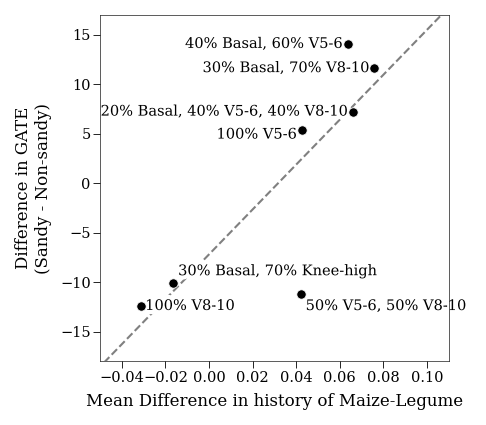

In [110]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
var_smd_atedif = get_smd_atedif('history_maizelegume')


res = stats.linregress(var_smd_atedif['SMD'], var_smd_atedif['ATE Difference'])
x_ticks = np.arange(-.2, .5, .02)
ax.plot(
    x_ticks, res.intercept + res.slope*x_ticks, 
    linestyle='--', color='gray', linewidth=1, zorder=1
)
ax.set_xticks(x_ticks)
ax.set_yticks(np.arange(-15, 25, 5))

sns.scatterplot(
    var_smd_atedif, x='SMD', y='ATE Difference', ax=ax,
    color='k', zorder=2 , s=20
)
ax.set_ylabel('Difference in GATE\n(Sandy - Non-sandy)')
ax.set_xlabel('Mean Difference in history of Maize-Legume')

left_labels = [
    '30% Basal, 70% Knee-high', '100% V8-10', '50% V5-6, 50% V8-10'
]
y_offset = {'30% Basal, 70% Knee-high': 1.2, '50% V5-6, 50% V8-10': -.5,
            '100% V5-6': -.5, '50% V5-6, 50% V8-10': -1.2}
for cluster_name, row in var_smd_atedif.iterrows():
    ax.text(
        row['SMD'], row['ATE Difference']+y_offset.get(cluster_name, 0), 
        f' {cluster_name} ', va='center',
        ha='left' if cluster_name in left_labels else 'right',
        linespacing=1, zorder=1, fontsize=7, 
        path_effects=[mpl.patheffects.withStroke(linewidth=4, foreground="w")]
        
    )


# ax.set_yticks(np.arange(-15, 20, 1), minor=True)
# ax.grid(axis='both', which='minor', linestyle=':')
ax.set_xlim(-.05, .11)
ax.set_ylim(-18, 17)

fig.savefig('../figures/N-fertilizer-split-soil-difference-legumemaize.pdf', bbox_inches='tight', dpi=300)


## Test difference between soil groups

In [111]:
# Create a DataFrame to store the difference in effects test results
diff_test_results = pd.DataFrame(
    columns=['Mean Difference (Non-sandy - Sandy)', 'SE Difference', 'Z-statistic', 'P-value']
)

def z_test_diff_means(mean1, mean2, se1, se2):
    diff_mean = mean1 - mean2
    se_diff = np.sqrt(se1**2 + se2**2)
    # Calculate the Z-statistic
    if se_diff != 0:
        z_statistic = diff_mean / se_diff
        p_value = 2 * stats.norm.sf(np.abs(z_statistic))
    else:
        z_statistic = np.nan
        p_value = np.nan # Or 1.0 if diff_mean is also 0, but nan is safer for general case
    return z_statistic, p_value

from itertools import combinations
def pairwise_ztest(df, grouping_col, compare_col, mean_col, se_col):
    out_df = []
    for g in df[grouping_col].unique():
        tmp_df = df.loc[df[grouping_col] == g].set_index(compare_col)
        # print(tmp_df)
        for g1, g2 in combinations(tmp_df.index, 2):
            if g1 == g2:
                continue
            mean1 = tmp_df.loc[g1, mean_col]
            mean2 = tmp_df.loc[g2, mean_col]
            se1 = tmp_df.loc[g1, se_col]
            se2 = tmp_df.loc[g2, se_col]
            z_statistic, p_value = z_test_diff_means(mean1, mean2, se1, se2)
            out_df.append((
                g, g1, g2, mean1 - mean2, z_statistic, p_value
            ))
    out_df = pd.DataFrame(
        out_df, 
        columns=[grouping_col, 'Group1', 'Group2', 'Diff', 'Zstat', 'pvalue']
    )
    return pd.DataFrame(out_df).set_index([grouping_col, 'Group1', 'Group2']).sort_index()
tmp_df = ate_df.reset_index()
tmp_df = tmp_df.loc[tmp_df['Soil'] != 'ATE']
pairwise_ztest(tmp_df, 'Estimate', 'Soil', 'Mean', "SE")

,,,Diff,Zstat,pvalue
Estimate,Group1,Group2,,,
Amount Cat.,Non-sandy,Sandy,1.634171,0.529069,0.596757
Amount rate,Non-sandy,Sandy,1.154730,0.307834,0.758209
Appl. Strat.,Non-sandy,Sandy,2.114199,0.765653,0.443883
No Het.,Non-sandy,Sandy,2.302557,0.889451,0.373761


In [112]:
tmp_df = timing_coefs.reset_index()
pairwise_ztest(tmp_df, 'level_1', 'level_0', 'point_estimate', "stderr")

,,,Diff,Zstat,pvalue
level_1,Group1,Group2,,,
100% V5-6,Non-sandy,Sandy,-5.401,-0.626029,0.531296
100% V8-10,Non-sandy,Sandy,12.409,1.586542,0.112617
"20% Basal, 40% V5-6, 40% V8-10",Non-sandy,Sandy,-7.222,-0.976988,0.328575
"30% Basal, 70% Knee-high",Non-sandy,Sandy,10.099,1.010509,0.312251
"30% Basal, 70% V8-10",Non-sandy,Sandy,-11.614,-1.185836,0.235687
"40% Basal, 60% V5-6",Non-sandy,Sandy,-14.059,-0.784316,0.432855
"50% V5-6, 50% V8-10",Non-sandy,Sandy,11.220,2.503623,0.012293
Other,Non-sandy,Sandy,5.584,1.032801,0.301697


In [113]:
timing_pairwise = pairwise_ztest(tmp_df, 'level_0', 'level_1', 'point_estimate', "stderr")
timing_pairwise.loc[timing_pairwise.pvalue<0.05]

Diff  \
level_0   Group1                         Group2                             
Non-sandy 100% V5-6                      30% Basal, 70% Knee-high -23.117   
          20% Basal, 40% V5-6, 40% V8-10 30% Basal, 70% Knee-high -21.408   
          30% Basal, 70% Knee-high       50% V5-6, 50% V8-10       15.579   
          Other                          30% Basal, 70% Knee-high -17.125   
Sandy     100% V8-10                     30% Basal, 70% V8-10     -19.874   
          30% Basal, 70% Knee-high       50% V5-6, 50% V8-10       16.700   
          30% Basal, 70% V8-10           50% V5-6, 50% V8-10       22.956   
          Other                          30% Basal, 70% V8-10     -18.866   

                                                                      Zstat  \
level_0   Group1                         Group2                               
Non-sandy 100% V5-6                      30% Basal, 70% Knee-high -2.322073   
          20% Basal, 40% V5-6, 40% V8-10 30% Basal, 70% Knee-high -2.563631   
          30% Basal, 70% Knee-high       50% V5-6, 50% V8-10       1.978108   
          Other                          30% Basal, 70% Knee-high -2.044917   
Sandy     100% V8-10                     30% Basal, 70% V8-10     -2.310015   
          30% Basal, 70% Knee-high       50% V5-6, 50% V8-10       2.194017   
          30% Basal, 70% V8-10           50% V5-6, 50% V8-10       2.684336   
          Other                          30% Basal, 70% V8-10     -2.190499   

                                                                     pvalue  
level_0   Group1                         Group2                              
Non-sandy 100% V5-6                      30% Basal, 70% Knee-high  0.020229  
          20% Basal, 40% V5-6, 40% V8-10 30% Basal, 70% Knee-high  0.010358  
          30% Basal, 70% Knee-high       50% V5-6, 50% V8-10       0.047917  
          Other                          30% Basal, 70% Knee-high  0.040863  
Sandy     100% V8-10                     30% Basal, 70% V8-10      0.020887  
          30% Basal, 70% Knee-high       50% V5-6, 50% V8-10       0.028234  
          30% Basal, 70% V8-10           50% V5-6, 50% V8-10       0.007267  
          Other                          30% Basal, 70% V8-10      0.028488

## Comparing features for signficantly different splitting strategies

In [114]:
# Best for sandy soils
def get_data_for_smd(soil_sandy, cluster_timing_map):
    tmp_df = transformed_data_pstrimmed.copy()
    cols_to_drop = ['lat', 'lon', 'outcome_prodstd', 'crop_maize']
    cols_to_drop += list(tmp_df.filter(like='season').columns[4:])
    cols_to_drop += list(tmp_df.filter(like='timing').columns)
    cols_to_drop += list(tmp_df.filter(like='fert').columns)
    tmp_df = tmp_df.drop(columns=cols_to_drop)
    tmp_df = data[tmp_df.columns].copy()
    tmp_df = tmp_df.loc[tmp_df['soil_sandy'] == soil_sandy]
    tmp_df = tmp_df.drop(columns=tmp_df.filter(like='soil').columns)
    tmp_df['weights'] = sample_weights[transformed_data_pstrimmed.index]
    tmp_df['strategy'] = appl_clusters_df['Cluster name'].map(cluster_timing_map)
    tmp_df = tmp_df.dropna(subset=['strategy'])
    return tmp_df

In [115]:
def smd_weighted(df, group_col, weight_col, ignore_cols=None):
    """
    Computes the Standardized Mean Difference (SMD) between two groups in a DataFrame,
    using provided weights.

    Args:
        df (pd.DataFrame): The input DataFrame containing features, group assignments, and weights.
        group_col (str): The name of the column that defines the two groups.
                         This column must have exactly two unique non-NaN values.
        weight_col (str): The name of the column containing the sample weights.
        ignore_cols (list, optional): A list of column names to ignore when calculating SMD.
                                       These columns will not be treated as covariates.
                                       Defaults to None.

    Returns:
        pd.Series: A Series where the index is the feature name and values are their SMDs.
    """
    if ignore_cols is None:
        ignore_cols = []
    
    df_filtered = df.dropna(subset=[group_col]).copy()
    unique_groups = df_filtered[group_col].unique()
    if len(unique_groups) != 2:
        raise ValueError(
            f"The '{group_col}' column must contain exactly two unique groups after dropping NaNs. "
            f"Found: {unique_groups}"
        )

    group1_val, group2_val = 'Best', 'Worst'
    df1 = df_filtered[df_filtered[group_col] == group1_val]
    df2 = df_filtered[df_filtered[group_col] == group2_val]
    covariate_cols = []
    for dtype in [np.number, bool]:
        covariate_cols.extend([
            col for col in df_filtered.select_dtypes(include=dtype).columns
            if col not in [group_col, weight_col] + ignore_cols
        ])
    covariate_cols = list(pd.unique(covariate_cols))
    
    smd_results = {}

    for feat in covariate_cols:
        mean1 = (df1[feat] * df1[weight_col]).sum() / df1[weight_col].sum()
        mean2 = (df2[feat] * df2[weight_col]).sum() / df2[weight_col].sum()
        overall_mean = (df_filtered[feat] * df_filtered[weight_col]).sum() / df_filtered[weight_col].sum()
        overall_std = np.sqrt(
            (df_filtered[weight_col] * (df_filtered[feat] - overall_mean)**2).sum() / df_filtered[weight_col].sum()
        )
        if overall_std == 0:
            smd = 0.0 
        else:
            smd = (mean1 - mean2) / overall_std
        smd_results[feat] = smd
    return pd.Series(smd_results)

# Compute the weighted SMD for the relevant columns

cluster_timing_map = {
        '30Basal_70Kneehigh': 'Best', '30Basal_70V810': 'Best',
        '100V810': 'Worst', '50V56_50V810': 'Worst'
    }
smd_strategy_comparison = smd_weighted(get_data_for_smd(1, cluster_timing_map), 'strategy', 'weights')
smd_strategy_comparison = smd_strategy_comparison.to_frame(name='Sandy')
cluster_timing_map = {
        '30Basal_70Kneehigh': 'Best', '100V56': 'Worst',
        '20Basal_40V56_40V810': 'Worst'
    }
smd_strategy_comparison['Non-sandy'] = smd_weighted(get_data_for_smd(0, cluster_timing_map), 'strategy', 'weights')
smd_strategy_comparison = smd_strategy_comparison.sort_index()

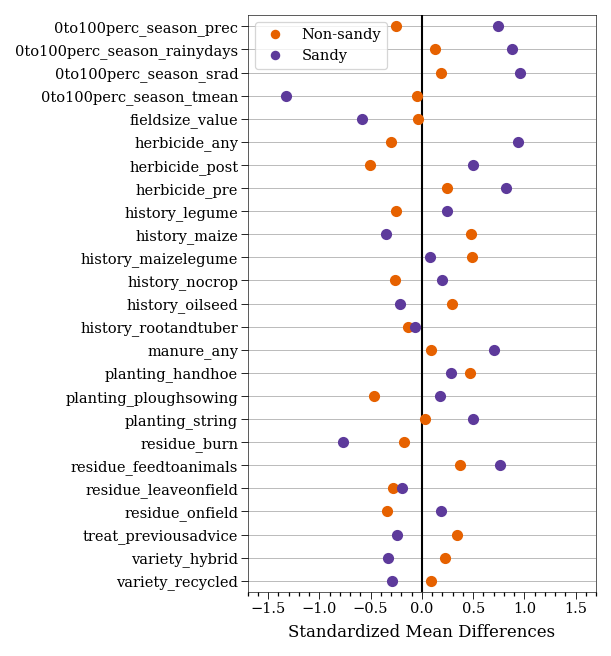

In [116]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

ax.axvline(0, color='k', linestyle='-')
# ax.axvline(0.1, color='k', linestyle='--', linewidth=1)
# ax.axvline(-0.1, color='k', linestyle='--', linewidth=1)
sns.pointplot(
    smd_strategy_comparison.reset_index(), y='index', x='Non-sandy', label='Non-sandy', markersize=4,
    linestyles='', ax=ax
)
sns.pointplot(
    smd_strategy_comparison.reset_index(), y='index', x='Sandy', label='Sandy', markersize=4,
    linestyles='', ax=ax
)

ax.set_xlabel('Standardized Mean Differences')
ax.set_ylabel('')
ax.set_xticks(np.arange(-2, 2, 0.5))
ax.set_xticks(np.arange(-2, 2, 0.1), minor=True)
ax.set_xlim(-1.7, 1.7)
# ax.grid(which='minor', linestyle=':')

# ax.grid(which='major', linestyle='')
ax.grid(axis='y', linestyle='-')
fig.savefig('../figures/smd-best-worst-N-fertilizer-split.pdf', bbox_inches='tight', dpi=300)

In [117]:
np.sqrt((7.4**2 + 17.6**2 +8.4**2)/3)